<a href="https://colab.research.google.com/github/Docdoi/AI-Engineered_Nanoproteins_A_De_Novo_Approach_to_Inhibit_Hantavirus_Transmission-/blob/main/Diffusion2_6y5wB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Clone RFdiffusion original
%cd /content

!git clone https://github.com/RosettaCommons/RFdiffusion.git

%cd /content/RFdiffusion

/content
fatal: destination path 'RFdiffusion' already exists and is not an empty directory.
/content/RFdiffusion


In [2]:
#Install micromamba
%cd /content

!mkdir -p /content/bin
!curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest \
  | tar -xvj -C /content/bin --strip-components=1 bin/micromamba

!/content/bin/micromamba --version

/content
bin/micromamba
2.9.0


In [3]:
#Python 3.9 environment
!/content/bin/micromamba create -y \
  -p /content/rfd1_env \
  -c conda-forge \
  python=3.9 \
  pip

Using Cached Shard Index for conda-forge/linux-64                                                   ✔ Done
Using Cached Shard Index for conda-forge/noarch                                                     ✔ Done
Fetching and Parsing Packages' Shards                                                     ✔ Done (0.3 sec)

Resolving Environment                                                                     ✔ Done (0.3 sec)

Transaction

  Prefix: /content/rfd1_env

  Updating specs:

   - python=3.9
   - pip


  Package               Version  Build                 Channel           Size
───────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────

  + _openmp_mutex           4.5  20_gnu                conda-forge     Cached
  + bzip2                 1.0.8  hda65f42_10           conda-forge     Cached
  + ca-certificates   2026.7.22  hbd8a1cb_0            conda-forge     Cache

In [4]:
!/content/bin/micromamba run \
  -p /content/rfd1_env \
  python --version

Python 3.9.23


In [5]:
#PyTorch 1.12.1 + CUDA 11.6
!/content/bin/micromamba run \
  -p /content/rfd1_env \
  pip install --no-cache-dir \
  "numpy<2" \
  torch==1.12.1+cu116 \
  --extra-index-url https://download.pytorch.org/whl/cu116

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu116
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 GB 185.3 MB/s  0:00:10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 216.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torch]


In [6]:
!/content/bin/micromamba run \
  -p /content/rfd1_env \
  python -c "import torch; print('Torch:', torch.__version__); print('CUDA:', torch.version.cuda); print('CUDA available:', torch.cuda.is_available()); print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE')"

Torch: 1.12.1+cu116
CUDA: 11.6
CUDA available: True
GPU: Tesla T4


In [7]:
#DGL 1.0.2 cu116
!/content/bin/micromamba run \
  -p /content/rfd1_env \
  pip install --no-cache-dir \
  dgl==1.0.2+cu116 \
  -f https://data.dgl.ai/wheels/cu116/repo.html

Looking in links: https://data.dgl.ai/wheels/cu116/repo.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 MB 55.8 MB/s  0:00:04
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 317.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [dgl]


In [8]:
!/content/bin/micromamba run \
  -p /content/rfd1_env \
  python -c "import dgl; print('DGL:', dgl.__version__)"

DGL backend not selected or invalid.  Assuming PyTorch for now.
Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/content/rfd1_env/lib/python3.9/site-packages/dgl/__init__.py", line 18, in <module>
    from .backend import load_backend, backend_name
  File "/content/rfd1_env/lib/python3.9/site-packages/dgl/backend/__init__.py", line 122, in <module>
    load_backend(get_preferred_backend())
  File "/content/rfd1_env/lib/python3.9/site-packages/dgl/backend/__init__.py", line 51, in load_backend
    from .._ffi.base import load_tensor_adapter  # imports DGL C library
  File "/content/rfd1_env/lib/python3.9/site-packages/dgl/_ffi/base.py", line 50, in <module>
    _LIB, _LIB_NAME, _DIR_NAME = _load_lib()
  File "/content/rfd1_env/lib/python3.9/site-packages/d

In [9]:
!/content/bin/micromamba install -y \
  -p /content/rfd1_env \
  -c conda-forge \
  cudatoolkit=11.6

Using Cached Shard Index for conda-forge/linux-64                                                   ✔ Done
Using Cached Shard Index for conda-forge/noarch                                                     ✔ Done
Fetching and Parsing Packages' Shards                                                     ✔ Done (0.2 sec)

Pinned packages:

  - python=3.9

Resolving Environment                                                                     ✔ Done (0.4 sec)

Transaction

  Prefix: /content/rfd1_env

  Updating specs:

   - cudatoolkit=11.6


  Package         Version  Build        Channel          Size
───────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────

  + cudatoolkit    11.6.2  hfc3e2af_13  conda-forge     628MB
  + libgcc-ng      16.2.0  h69a702a_4   conda-forge      28kB
  + libstdcxx-ng   16.2.0  hdf11a46_4   conda-forge      28kB

  Summary:

  Install: 3 packages

  Total download: 628MB

──

In [10]:
!find /content/rfd1_env -name "libcusparse.so*" -print

/content/rfd1_env/lib/libcusparse.so
/content/rfd1_env/lib/libcusparse.so.11
/content/rfd1_env/lib/libcusparse.so.11.7.2.124


In [11]:
!DGLBACKEND=pytorch \
LD_LIBRARY_PATH=/content/rfd1_env/lib:$LD_LIBRARY_PATH \
/content/bin/micromamba run \
-p /content/rfd1_env \
python -c "import dgl; print('DGL:', dgl.__version__)"

DGL: 1.0.2+cu116


In [12]:
!DGLBACKEND=pytorch \
LD_LIBRARY_PATH=/content/rfd1_env/lib:$LD_LIBRARY_PATH \
/content/bin/micromamba run \
-p /content/rfd1_env \
python -c "import torch,dgl; print('Torch:',torch.__version__); print('CUDA:',torch.version.cuda); print('GPU:',torch.cuda.get_device_name(0)); print('DGL:',dgl.__version__); print('Torch + DGL OK')"

Torch: 1.12.1+cu116
CUDA: 11.6
GPU: Tesla T4
DGL: 1.0.2+cu116
Torch + DGL OK


In [13]:
#SE3Transformer for RFdiffusion original

%cd /content/RFdiffusion

!DGLBACKEND=pytorch \
LD_LIBRARY_PATH=/content/rfd1_env/lib:$LD_LIBRARY_PATH \
/content/bin/micromamba run \
-p /content/rfd1_env \
pip install --no-cache-dir ./env/SE3Transformer

/content/RFdiffusion
Processing ./env/SE3Transformer
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'se3-transformer' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'se3-transformer'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for se3-transformer: filename=se3_transformer-1.0.0-py3-none-any.whl size=50903 sha256=95107599b118484e5fafa55081ef70afe7af971c64853cf9685249083e67cf8e
  Stored in directory: /tmp/pip-ephem-wheel-cache-ou53dqtm/wheels/4a/c4/78/528d473126524a5137099365ef33372dbe5a8b614e12973b1d
Successfully built se3-transformer


In [14]:
!DGLBACKEND=pytorch \
LD_LIBRARY_PATH=/content/rfd1_env/lib:$LD_LIBRARY_PATH \
/content/bin/micromamba run \
-p /content/rfd1_env \
python -c "import se3_transformer; print('SE3Transformer import OK')"

SE3Transformer import OK


In [15]:
#left dependency

!/content/bin/micromamba run \
-p /content/rfd1_env \
pip install --no-cache-dir \
e3nn==0.3.3 \
hydra-core==1.3.2 \
pyrsistent==0.19.3 \
decorator==5.1.0 \
icecream \
scipy \
opt_einsum

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 119.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.8/750.8 kB 707.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 293.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 693.1 MB/s  0:00:00
  DEPRECATION: Building 'antlr4-python3-runtime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'antlr4-python3-runtime'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.3-py3-none-any.whl size=144591 sha256=934ab0d8794ae01f2b4242e92ca6e3368e430e4771165

In [16]:
#setting RFdiffusion original

%cd /content/RFdiffusion

!/content/bin/micromamba run \
-p /content/rfd1_env \
pip install -e . --no-deps

/content/RFdiffusion
Obtaining file:///content/RFdiffusion
  Preparing metadata (setup.py) ... done
  DEPRECATION: Legacy editable install of rfdiffusion==1.1.0 from file:///content/RFdiffusion (setup.py develop) is deprecated. pip 25.3 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
  Running setup.py develop for rfdiffusion


In [17]:
!DGLBACKEND=pytorch \
LD_LIBRARY_PATH=/content/rfd1_env/lib:$LD_LIBRARY_PATH \
PYTHONPATH=/content/RFdiffusion \
/content/bin/micromamba run \
-p /content/rfd1_env \
python -c "import torch, dgl, rfdiffusion; print('RFdiffusion original import OK'); print('Torch:',torch.__version__); print('DGL:',dgl.__version__)"

RFdiffusion original import OK
Torch: 1.12.1+cu116
DGL: 1.0.2+cu116


In [18]:
#checkpoint exist or not

!find /content/RFdiffusion -type f \
  \( -name "*.pt" -o -name "*.pkl" \) \
  -print

/content/RFdiffusion/examples/tim_barrel_scaffold/6WVS_ss.pt
/content/RFdiffusion/examples/tim_barrel_scaffold/6WVS_adj.pt
/content/RFdiffusion/examples/target_folds/insulin_target_adj.pt
/content/RFdiffusion/examples/target_folds/insulin_target_ss.pt


In [19]:
!mkdir -p /content/RFdiffusion/models

In [20]:
!wget -O /content/RFdiffusion/models/Complex_base_ckpt.pt \
https://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Complex_base_ckpt.pt

--2026-08-28 14:22:20--  https://files.ipd.uw.edu/pub/RFdiffusion/6f5902ac237024bdd0c176cb93063dc4/Complex_base_ckpt.pt
Resolving files.ipd.uw.edu (files.ipd.uw.edu)... 128.95.160.135, 128.95.160.134, 2607:4000:406::160:135, ...
Connecting to files.ipd.uw.edu (files.ipd.uw.edu)|128.95.160.135|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-28 14:22:20 ERROR 404: Not Found.



In [21]:
!ls -lh /content/RFdiffusion/models/Complex_base_ckpt.pt

-rw-r--r-- 1 root root 0 Aug 28 14:22 /content/RFdiffusion/models/Complex_base_ckpt.pt


In [22]:
!test -f /content/RFdiffusion/models/Complex_base_ckpt.pt && echo "✅ Complex_base_ckpt.pt found"

✅ Complex_base_ckpt.pt found


In [23]:
PDB_FILE = "/content/6y5wB.pdb"

chains = {}

with open(PDB_FILE) as f:
    for line in f:
        if line.startswith("ATOM"):
            chain = line[21].strip() or "_"
            resi = int(line[22:26])

            if chain not in chains:
                chains[chain] = set()

            chains[chain].add(resi)

print("PDB:", PDB_FILE)

for chain, residues in chains.items():
    residues = sorted(residues)
    print(
        f"Chain {chain}: "
        f"{residues[0]}-{residues[-1]} "
        f"({len(residues)} residues)"
    )

PDB: /content/6y5wB.pdb
Chain B: 659-1069 (405 residues)


In [24]:
PDB_FILE = "/content/6y5wB.pdb"

# ===== RFdiffusion settings =====

CONTIGS = "B703-950/0 50-70"

HOTSPOTS = ["B739", "B766", "B900"]

NUM_DESIGNS = 5

OUTPUT_PREFIX = "/content/rfd1_outputs/design"

In [25]:
f"contigmap.contigs=[{CONTIGS}]"

'contigmap.contigs=[B703-950/0 50-70]'

In [26]:
!ls -lh /content/RFdiffusion/models/Complex_base_ckpt.pt
!stat -c "%s bytes" /content/RFdiffusion/models/Complex_base_ckpt.pt

-rw-r--r-- 1 root root 0 Aug 28 14:22 /content/RFdiffusion/models/Complex_base_ckpt.pt
0 bytes


In [27]:
!rm -f /content/RFdiffusion/models/Complex_base_ckpt.pt

!wget -O /content/RFdiffusion/models/Complex_base_ckpt.pt \
http://files.ipd.uw.edu/pub/RFdiffusion/e29311f6f1bf1af907f9ef9f44b8328b/Complex_base_ckpt.pt

--2026-08-28 14:22:21--  http://files.ipd.uw.edu/pub/RFdiffusion/e29311f6f1bf1af907f9ef9f44b8328b/Complex_base_ckpt.pt
Resolving files.ipd.uw.edu (files.ipd.uw.edu)... 128.95.160.135, 128.95.160.134, 2607:4000:406::160:135, ...
Connecting to files.ipd.uw.edu (files.ipd.uw.edu)|128.95.160.135|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 483619179 (461M) [application/octet-stream]
Saving to: ‘/content/RFdiffusion/models/Complex_base_ckpt.pt’

/content/RFdiffusio 100%[===================>] 461.21M  22.4MB/s    in 20s     

2026-08-28 14:22:41 (23.1 MB/s) - ‘/content/RFdiffusion/models/Complex_base_ckpt.pt’ saved [483619179/483619179]



In [28]:
!ls -lh /content/RFdiffusion/models/Complex_base_ckpt.pt
!stat -c "Size = %s bytes" /content/RFdiffusion/models/Complex_base_ckpt.pt

-rw-r--r-- 1 root root 462M Mar 30  2023 /content/RFdiffusion/models/Complex_base_ckpt.pt
Size = 483619179 bytes


In [29]:
!LD_LIBRARY_PATH=/content/rfd1_env/lib:$LD_LIBRARY_PATH \
/content/bin/micromamba run -p /content/rfd1_env \
python -c "import torch; p='/content/RFdiffusion/models/Complex_base_ckpt.pt'; c=torch.load(p,map_location='cpu'); print('✅ Checkpoint load OK'); print(c.keys())"

✅ Checkpoint load OK
dict_keys(['model_state_dict', 'final_state_dict', 'config_dict'])


In [30]:
#RFdiffusion
import os
import subprocess

os.makedirs("/content/rfd1_outputs", exist_ok=True)

hotspots = ",".join(HOTSPOTS)

cmd = [
    "/content/bin/micromamba", "run",
    "-p", "/content/rfd1_env",
    "python",
    "/content/RFdiffusion/scripts/run_inference.py",

    f"inference.input_pdb={PDB_FILE}",
    f"inference.output_prefix={OUTPUT_PREFIX}",

    # บอก checkpoint ให้ชัดเจน
    "inference.ckpt_override_path=/content/RFdiffusion/models/Complex_base_ckpt.pt",

    f"contigmap.contigs=[{CONTIGS}]",
    f"ppi.hotspot_res=[{hotspots}]",
    f"inference.num_designs={NUM_DESIGNS}",
]

env = os.environ.copy()

env["DGLBACKEND"] = "pytorch"
env["LD_LIBRARY_PATH"] = (
    "/content/rfd1_env/lib:" +
    env.get("LD_LIBRARY_PATH", "")
)

env["PYTHONPATH"] = (
    "/content/RFdiffusion:" +
    env.get("PYTHONPATH", "")
)

env["HYDRA_FULL_ERROR"] = "1"

print("Running RFdiffusion...")
print("PDB       :", PDB_FILE)
print("CONTIGS   :", CONTIGS)
print("HOTSPOTS  :", HOTSPOTS)
print("DESIGNS   :", NUM_DESIGNS)
print("CHECKPOINT:", "/content/RFdiffusion/models/Complex_base_ckpt.pt")
print()

result = subprocess.run(
    cmd,
    env=env,
    text=True,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

print(result.stdout)
print("\nReturn code:", result.returncode)

Running RFdiffusion...
PDB       : /content/6y5wB.pdb
CONTIGS   : B703-950/0 50-70
HOTSPOTS  : ['B739', 'B766', 'B900']
DESIGNS   : 5
CHECKPOINT: /content/RFdiffusion/models/Complex_base_ckpt.pt

[2026-08-28 14:22:46,488][__main__][INFO] - Found GPU with device_name Tesla T4. Will run RFdiffusion on Tesla T4
Reading models from /content/RFdiffusion/rfdiffusion/inference/../../models
[2026-08-28 14:22:46,489][rfdiffusion.inference.model_runners][INFO] - Reading checkpoint from /content/RFdiffusion/models/Complex_base_ckpt.pt
This is inf_conf.ckpt_path
/content/RFdiffusion/models/Complex_base_ckpt.pt
Assembling -model, -diffuser and -preprocess configs from checkpoint
USING MODEL CONFIG: self._conf[model][n_extra_block] = 4
USING MODEL CONFIG: self._conf[model][n_main_block] = 32
USING MODEL CONFIG: self._conf[model][n_ref_block] = 4
USING MODEL CONFIG: self._conf[model][d_msa] = 256
USING MODEL CONFIG: self._conf[model][d_msa_full] = 64
USING MODEL CONFIG: self._conf[model][d_pair] = 12

In [31]:
#mpnn

In [32]:
%cd /content
!git clone https://github.com/dauparas/ProteinMPNN.git

/content
Cloning into 'ProteinMPNN'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (271/271), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 634 (delta 151), reused 146 (delta 146), pack-reused 363 (from 1)
Receiving objects: 100% (634/634), 119.90 MiB | 26.18 MiB/s, done.
Resolving deltas: 100% (290/290), done.


In [33]:
!/content/bin/micromamba run \
-p /content/rfd1_env \
python -c "import torch; print(torch.__version__)"

1.12.1+cu116


In [34]:
from pathlib import Path

for pdb in sorted(Path("/content/rfd1_outputs").glob("design_*.pdb")):
    chains = set()

    with open(pdb) as f:
        for line in f:
            if line.startswith("ATOM"):
                chains.add(line[21].strip())

    print(pdb.name, "chains:", sorted(chains))

design_0.pdb chains: ['A', 'B']
design_1.pdb chains: ['A', 'B']
design_2.pdb chains: ['A', 'B']
design_3.pdb chains: ['A', 'B']
design_4.pdb chains: ['A', 'B']


In [35]:
!/content/bin/micromamba run \
-p /content/rfd1_env \
python helper_scripts/assign_fixed_chains.py \
--input_path=/content/rfd1_outputs/parsed_pdbs.jsonl \
--output_path=/content/rfd1_outputs/assigned_pdbs.jsonl \
--chain_list "A"

python: can't open file '/content/helper_scripts/assign_fixed_chains.py': [Errno 2] No such file or directory


In [36]:
%cd /content

!git clone https://github.com/dauparas/ProteinMPNN.git

/content
fatal: destination path 'ProteinMPNN' already exists and is not an empty directory.


In [37]:
!ls /content/ProteinMPNN/helper_scripts

assign_fixed_chains.py		     make_tied_positions_dict.py
make_bias_AA.py			     other_tools
make_bias_per_res_dict.py	     parse_multiple_chains.out
make_fixed_positions_dict.py	     parse_multiple_chains.py
make_pos_neg_tied_positions_dict.py  parse_multiple_chains.sh
make_pssm_input_dict.py


In [38]:
from pathlib import Path

for pdb in sorted(Path("/content/rfd1_outputs").glob("design_*.pdb")):
    chains = {}

    with open(pdb) as f:
        for line in f:
            if line.startswith("ATOM"):
                chain = line[21].strip()
                resi = int(line[22:26])

                if chain not in chains:
                    chains[chain] = set()

                chains[chain].add(resi)

    print("\n", pdb.name)

    for chain, residues in chains.items():
        print(
            f"  Chain {chain}: "
            f"{min(residues)}-{max(residues)} "
            f"({len(residues)} residues)"
        )


 design_0.pdb
  Chain A: 1-67 (67 residues)
  Chain B: 703-950 (248 residues)

 design_1.pdb
  Chain A: 1-59 (59 residues)
  Chain B: 703-950 (248 residues)

 design_2.pdb
  Chain A: 1-65 (65 residues)
  Chain B: 703-950 (248 residues)

 design_3.pdb
  Chain A: 1-62 (62 residues)
  Chain B: 703-950 (248 residues)

 design_4.pdb
  Chain A: 1-58 (58 residues)
  Chain B: 703-950 (248 residues)


In [39]:
%cd /content/ProteinMPNN

!/content/bin/micromamba run \
-p /content/rfd1_env \
python helper_scripts/parse_multiple_chains.py \
--input_path=/content/rfd1_outputs \
--output_path=/content/rfd1_outputs/parsed_pdbs.jsonl

/content/ProteinMPNN


In [40]:
!/content/bin/micromamba run \
-p /content/rfd1_env \
python /content/ProteinMPNN/helper_scripts/assign_fixed_chains.py \
--input_path=/content/rfd1_outputs/parsed_pdbs.jsonl \
--output_path=/content/rfd1_outputs/assigned_pdbs.jsonl \
--chain_list "A"

In [41]:
%cd /content/ProteinMPNN

!/content/bin/micromamba run \
-p /content/rfd1_env \
python protein_mpnn_run.py \
--jsonl_path /content/rfd1_outputs/parsed_pdbs.jsonl \
--chain_id_jsonl /content/rfd1_outputs/assigned_pdbs.jsonl \
--out_folder /content/mpnn_outputs \
--num_seq_per_target 8 \
--sampling_temp "0.1" \
--seed 37 \
--batch_size 1

/content/ProteinMPNN
----------------------------------------
fixed_positions_jsonl is NOT loaded
----------------------------------------
pssm_jsonl is NOT loaded
----------------------------------------
omit_AA_jsonl is NOT loaded
----------------------------------------
bias_AA_jsonl is NOT loaded
----------------------------------------
tied_positions_jsonl is NOT loaded
----------------------------------------
bias by residue dictionary is not loaded, or not provided
----------------------------------------
discarded {'bad_chars': 0, 'too_long': 0, 'bad_seq_length': 0}
----------------------------------------
Number of edges: 48
Training noise level: 0.2A
Generating sequences for: design_1
8 sequences of length 307 generated in 9.6099 seconds
Generating sequences for: design_4
8 sequences of length 306 generated in 9.1415 seconds
Generating sequences for: design_2
8 sequences of length 313 generated in 9.375 seconds
Generating sequences for: design_0
8 sequences of length 315 gene

In [42]:
from pathlib import Path

seq_dir = Path("/content/mpnn_outputs/seqs")

files = sorted(seq_dir.glob("*.fa"))

print("Found", len(files), "FASTA files")

for fa in files:
    print("\n==============================")
    print(fa.name)
    print("==============================")
    print(fa.read_text())

Found 5 FASTA files

design_0.fa
>design_0, score=2.3528, global_score=1.9579, fixed_chains=['B'], designed_chains=['A'], model_name=v_48_020, git_hash=8907e6671bfbfc92303b5f79c4b5e6ce47cdef57, seed=37
GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG
>T=0.1, sample=1, score=1.1469, global_score=1.7113, seq_recovery=0.0000
SISPADFAALAAAAIARLETAAAAAAAWLEANRASLSDVAAAEAAIAALRAAAAAARAAAAAALAAM
>T=0.1, sample=2, score=1.3606, global_score=1.7535, seq_recovery=0.0000
SLSKEEFAALCAAEIQRLETRVEALRAWLEANKERLADVAAHEAEIEALEAEAAALKAQCEALLAAM
>T=0.1, sample=3, score=1.2114, global_score=1.7156, seq_recovery=0.0000
SVSAADLAAKYAAEIAKAETAVAAAEAALAANREKLENVAEAKAAIEAAKAAVAALKAEAAAELAAL
>T=0.1, sample=4, score=1.1344, global_score=1.6762, seq_recovery=0.0000
TVSPEELAARAAAAIRRLETAVAAAEAALAANAASLSNVAAAQAAIAAARAKVAAARAAAAAELAAM
>T=0.1, sample=5, score=1.2422, global_score=1.7197, seq_recovery=0.0000
AVSPEELAARLAKEIAKAETRAAAAAAALEANRASLEDVAAALAAIAALRAAVAAARAAAAALLAAL
>T=0.1, sample=6, score=1

In [43]:
from pathlib import Path

search_dirs = [
    Path("/content/rfd1_outputs"),
    Path("/content/ProteinMPNN"),
]

fasta_files = []

for d in search_dirs:
    if d.exists():
        fasta_files.extend(d.rglob("design_*.fa"))
        fasta_files.extend(d.rglob("design_*.fasta"))

fasta_files = sorted(set(fasta_files))

print(f"Found {len(fasta_files)} FASTA files\n")

for f in fasta_files:
    print(f)

Found 0 FASTA files



In [44]:
from pathlib import Path

fasta_files = []

for ext in ("*.fa", "*.fasta", "*.faa"):
    fasta_files.extend(Path("/content").rglob(ext))

fasta_files = sorted(set(fasta_files))

print(f"Found {len(fasta_files)} FASTA-like files\n")

for f in fasta_files:
    print(f)

Found 23 FASTA-like files

/content/ProteinMPNN/outputs/example_1_outputs/seqs/5L33.fa
/content/ProteinMPNN/outputs/example_1_outputs/seqs/6MRR.fa
/content/ProteinMPNN/outputs/example_2_outputs/seqs/3HTN.fa
/content/ProteinMPNN/outputs/example_2_outputs/seqs/4YOW.fa
/content/ProteinMPNN/outputs/example_3_outputs/seqs/3HTN.fa
/content/ProteinMPNN/outputs/example_4_non_fixed_outputs/seqs/3HTN.fa
/content/ProteinMPNN/outputs/example_4_non_fixed_outputs/seqs/4YOW.fa
/content/ProteinMPNN/outputs/example_4_outputs/seqs/3HTN.fa
/content/ProteinMPNN/outputs/example_4_outputs/seqs/4YOW.fa
/content/ProteinMPNN/outputs/example_5_outputs/seqs/3HTN.fa
/content/ProteinMPNN/outputs/example_5_outputs/seqs/4YOW.fa
/content/ProteinMPNN/outputs/example_6_outputs/seqs/4GYT.fa
/content/ProteinMPNN/outputs/example_6_outputs/seqs/6EHB.fa
/content/ProteinMPNN/outputs/example_8_outputs/seqs/5L33.fa
/content/ProteinMPNN/outputs/example_8_outputs/seqs/6MRR.fa
/content/ProteinMPNN/outputs/example_pssm_outputs/seq

In [45]:
from pathlib import Path

SEQ_DIR = Path("/content/mpnn_outputs/seqs")

for fa in sorted(SEQ_DIR.glob("design_*.fa")):
    print("\n" + "="*80)
    print(fa.name)
    print("="*80)

    with open(fa) as f:
        print(f.read())


design_0.fa
>design_0, score=2.3528, global_score=1.9579, fixed_chains=['B'], designed_chains=['A'], model_name=v_48_020, git_hash=8907e6671bfbfc92303b5f79c4b5e6ce47cdef57, seed=37
GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG
>T=0.1, sample=1, score=1.1469, global_score=1.7113, seq_recovery=0.0000
SISPADFAALAAAAIARLETAAAAAAAWLEANRASLSDVAAAEAAIAALRAAAAAARAAAAAALAAM
>T=0.1, sample=2, score=1.3606, global_score=1.7535, seq_recovery=0.0000
SLSKEEFAALCAAEIQRLETRVEALRAWLEANKERLADVAAHEAEIEALEAEAAALKAQCEALLAAM
>T=0.1, sample=3, score=1.2114, global_score=1.7156, seq_recovery=0.0000
SVSAADLAAKYAAEIAKAETAVAAAEAALAANREKLENVAEAKAAIEAAKAAVAALKAEAAAELAAL
>T=0.1, sample=4, score=1.1344, global_score=1.6762, seq_recovery=0.0000
TVSPEELAARAAAAIRRLETAVAAAEAALAANAASLSNVAAAQAAIAAARAKVAAARAAAAAELAAM
>T=0.1, sample=5, score=1.2422, global_score=1.7197, seq_recovery=0.0000
AVSPEELAARLAKEIAKAETRAAAAAAALEANRASLEDVAAALAAIAALRAAVAAARAAAAALLAAL
>T=0.1, sample=6, score=1.2753, global_score=

In [46]:
from pathlib import Path

SEQ_DIR = Path("/content/mpnn_outputs/seqs")

for fa in sorted(SEQ_DIR.glob("design_*.fa")):

    print("\n" + "="*70)
    print(f" {fa.name}")
    print("="*70)

    with open(fa) as f:
        lines = [x.strip() for x in f if x.strip()]

    for line in lines:
        if line.startswith(">"):
            print("\n", line)
        else:
            parts = line.split("/")

            print("Number of chains:", len(parts))

            for i, seq in enumerate(parts):
                print(
                    f"  part {i+1}: "
                    f"length={len(seq)}  "
                    f"first20={seq[:20]}..."
                )


 design_0.fa

 >design_0, score=2.3528, global_score=1.9579, fixed_chains=['B'], designed_chains=['A'], model_name=v_48_020, git_hash=8907e6671bfbfc92303b5f79c4b5e6ce47cdef57, seed=37
Number of chains: 1
  part 1: length=67  first20=GGGGGGGGGGGGGGGGGGGG...

 >T=0.1, sample=1, score=1.1469, global_score=1.7113, seq_recovery=0.0000
Number of chains: 1
  part 1: length=67  first20=SISPADFAALAAAAIARLET...

 >T=0.1, sample=2, score=1.3606, global_score=1.7535, seq_recovery=0.0000
Number of chains: 1
  part 1: length=67  first20=SLSKEEFAALCAAEIQRLET...

 >T=0.1, sample=3, score=1.2114, global_score=1.7156, seq_recovery=0.0000
Number of chains: 1
  part 1: length=67  first20=SVSAADLAAKYAAEIAKAET...

 >T=0.1, sample=4, score=1.1344, global_score=1.6762, seq_recovery=0.0000
Number of chains: 1
  part 1: length=67  first20=TVSPEELAARAAAAIRRLET...

 >T=0.1, sample=5, score=1.2422, global_score=1.7197, seq_recovery=0.0000
Number of chains: 1
  part 1: length=67  first20=AVSPEELAARLAKEIAKAET...

 

In [47]:
from pathlib import Path

PDB_FILE = "/content/rfd1_outputs/design_0.pdb"

three_to_one = {
    "ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C",
    "GLN":"Q","GLU":"E","GLY":"G","HIS":"H","ILE":"I",
    "LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P",
    "SER":"S","THR":"T","TRP":"W","TYR":"Y","VAL":"V"
}

residues = {}

with open(PDB_FILE) as f:
    for line in f:
        if line.startswith("ATOM") and line[21].strip() == "B":
            resi = (int(line[22:26]), line[26])
            resn = line[17:20].strip()
            residues[resi] = resn

TARGET_SEQ = "".join(
    three_to_one.get(residues[r], "X")
    for r in sorted(residues)
)

print("Target length:", len(TARGET_SEQ))
print(TARGET_SEQ)

Target length: 248
SIPFHFQMEKQVIHAEIQPLGHWMDATFNIKTAFHCYGACQKYSYPWQTSKCFFEKDYQYETGWGCNPGDCPGVGTGCTACGVYLDKLKSVGKAYKIISLKYTRKVCIQLGTEQTCKHIDANDCLVTPSVKVCIVGTVSKLQPSDTLLFLGPLEQGGIILKQWCTTSCAFGDPGDIMSTPSGMRCPEHTGSFRKICGFATTPVCEYQGNTISGYKRMMATKDSFQSFNLTEPHITTNKLEWIDPDGNT


In [48]:
import re
from pathlib import Path

SEQ_DIR = Path("/content/mpnn_outputs/seqs")

best_sequences = {}

for fa in sorted(SEQ_DIR.glob("design_*.fa")):
    lines = [x.strip() for x in fa.read_text().splitlines() if x.strip()]

    candidates = []

    for i in range(0, len(lines), 2):
        header = lines[i]
        seq = lines[i+1]

        # ข้าม polyG/native sequence บรรทัดแรก
        if "sample=" not in header:
            continue

        score = float(re.search(r"score=([0-9.]+)", header).group(1))
        sample = int(re.search(r"sample=(\d+)", header).group(1))

        candidates.append((score, sample, seq))

    score, sample, seq = min(candidates, key=lambda x: x[0])

    best_sequences[fa.stem] = {
        "sample": sample,
        "score": score,
        "binder": seq
    }

    print(
        fa.stem,
        "sample =", sample,
        "score =", score,
        "binder length =", len(seq)
    )

design_0 sample = 4 score = 1.1344 binder length = 67
design_1 sample = 5 score = 1.1576 binder length = 59
design_2 sample = 3 score = 0.9769 binder length = 65
design_3 sample = 5 score = 1.2087 binder length = 62
design_4 sample = 4 score = 1.0727 binder length = 58


In [49]:
from pathlib import Path

AF2_INPUT = Path("/content/af2_inputs")
AF2_INPUT.mkdir(exist_ok=True)

for design, info in best_sequences.items():

    binder = info["binder"]

    complex_seq = f"{binder}:{TARGET_SEQ}"

    out = AF2_INPUT / f"{design}_best.fasta"

    out.write_text(
        f">{design}_sample{info['sample']}\n"
        f"{complex_seq}\n"
    )

    print(
        out.name,
        "| binder =", len(binder),
        "| target =", len(TARGET_SEQ),
        "| total =", len(binder) + len(TARGET_SEQ)
    )

design_0_best.fasta | binder = 67 | target = 248 | total = 315
design_1_best.fasta | binder = 59 | target = 248 | total = 307
design_2_best.fasta | binder = 65 | target = 248 | total = 313
design_3_best.fasta | binder = 62 | target = 248 | total = 310
design_4_best.fasta | binder = 58 | target = 248 | total = 306


In [50]:
import re
from pathlib import Path

# ============================================================
# Paths
# ============================================================

SEQ_DIR = Path("/content/mpnn_outputs/seqs")
RF_DIR = Path("/content/rfd1_outputs")

# ============================================================
# Convert Chain B target from RFdiffusion PDB -> sequence
# ============================================================

three_to_one = {
    "ALA":"A","ARG":"R","ASN":"N","ASP":"D","CYS":"C",
    "GLN":"Q","GLU":"E","GLY":"G","HIS":"H","ILE":"I",
    "LEU":"L","LYS":"K","MET":"M","PHE":"F","PRO":"P",
    "SER":"S","THR":"T","TRP":"W","TYR":"Y","VAL":"V"
}

target_pdb = RF_DIR / "design_0.pdb"

target_residues = {}

with open(target_pdb) as f:
    for line in f:
        if line.startswith("ATOM") and line[21].strip() == "B":
            key = (int(line[22:26]), line[26])
            target_residues[key] = line[17:20].strip()

TARGET_SEQ = "".join(
    three_to_one.get(target_residues[k], "X")
    for k in sorted(target_residues)
)

print("Target Chain B length:", len(TARGET_SEQ))

# ============================================================
# Select lowest-score ProteinMPNN sample per design
# ============================================================

best_sequences = {}

for fa in sorted(SEQ_DIR.glob("design_*.fa")):

    lines = [
        x.strip()
        for x in fa.read_text().splitlines()
        if x.strip()
    ]

    candidates = []

    for i in range(0, len(lines), 2):

        header = lines[i]
        seq = lines[i + 1]

        # Skip original poly-G sequence
        if "sample=" not in header:
            continue

        sample_match = re.search(r"sample=(\d+)", header)
        score_match = re.search(r"score=([0-9.]+)", header)

        if not sample_match or not score_match:
            continue

        sample = int(sample_match.group(1))
        score = float(score_match.group(1))

        candidates.append((score, sample, seq))

    score, sample, binder_seq = min(
        candidates,
        key=lambda x: x[0]
    )

    best_sequences[fa.stem] = {
        "sample": sample,
        "score": score,
        "binder": binder_seq
    }

    print(
        f"{fa.stem}: "
        f"sample={sample}, "
        f"MPNN score={score:.4f}, "
        f"binder={len(binder_seq)} aa"
    )

Target Chain B length: 248
design_0: sample=4, MPNN score=1.1344, binder=67 aa
design_1: sample=5, MPNN score=1.1576, binder=59 aa
design_2: sample=3, MPNN score=0.9769, binder=65 aa
design_3: sample=5, MPNN score=1.2087, binder=62 aa
design_4: sample=4, MPNN score=1.0727, binder=58 aa


In [51]:
from pathlib import Path

AF2_INPUT = Path("/content/af2_inputs")
AF2_INPUT.mkdir(exist_ok=True)

for design, info in best_sequences.items():

    binder = info["binder"]

    fasta = AF2_INPUT / f"{design}.fasta"

    fasta.write_text(
        f">{design}_sample{info['sample']}\n"
        f"{binder}:{TARGET_SEQ}\n"
    )

    print(
        f"{design}: "
        f"binder={len(binder)} aa + "
        f"target={len(TARGET_SEQ)} aa"
    )

design_0: binder=67 aa + target=248 aa
design_1: binder=59 aa + target=248 aa
design_2: binder=65 aa + target=248 aa
design_3: binder=62 aa + target=248 aa
design_4: binder=58 aa + target=248 aa


In [52]:
for f in sorted(AF2_INPUT.glob("*.fasta")):
    print(f)

/content/af2_inputs/design_0.fasta
/content/af2_inputs/design_0_best.fasta
/content/af2_inputs/design_1.fasta
/content/af2_inputs/design_1_best.fasta
/content/af2_inputs/design_2.fasta
/content/af2_inputs/design_2_best.fasta
/content/af2_inputs/design_3.fasta
/content/af2_inputs/design_3_best.fasta
/content/af2_inputs/design_4.fasta
/content/af2_inputs/design_4_best.fasta


In [53]:
%cd /content

!pip install -q --no-warn-conflicts \
"colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold"

!python -m colabfold.download

/content
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.1/264.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.0/101.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.1 MB/s eta 0:00:00
  file.extractall(path=params_dir)


In [54]:
!colabfold_batch --help | head -30

usage: colabfold_batch [-h] [--msa-only]
                       [--msa-mode {mmseqs2_uniref_env,mmseqs2_uniref_env_envpair,mmseqs2_uniref,single_sequence}]
                       [--pair-mode {unpaired,paired,unpaired_paired}]
                       [--pair-strategy {complete,greedy}] [--templates]
                       [--custom-template-path CUSTOM_TEMPLATE_PATH]
                       [--custom-template-cache-path CUSTOM_TEMPLATE_CACHE_PATH]
                       [--max-template-date MAX_TEMPLATE_DATE]
                       [--max-template-hits MAX_TEMPLATE_HITS]
                       [--pdb-hit-file PDB_HIT_FILE]
                       [--local-pdb-path LOCAL_PDB_PATH]
                       [--num-recycle NUM_RECYCLE]
                       [--recycle-early-stop-tolerance RECYCLE_EARLY_STOP_TOLERANCE]
                       [--num-ensemble NUM_ENSEMBLE] [--num-seeds NUM_SEEDS]
                       [--random-seed RANDOM_SEED] [--num-models {1,2,3,4,5}]
                       

In [55]:
import jax

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())

JAX version: 0.11.1
Devices: [CudaDevice(id=0)]


In [56]:
from pathlib import Path

AF2_OUTPUT = Path("/content/af2_results")
AF2_OUTPUT.mkdir(exist_ok=True)

print(AF2_OUTPUT)

/content/af2_results


In [57]:
#Alphafold

In [1]:
!pip uninstall -y jax jaxlib

!pip install \
  "jax==0.4.30" \
  "jaxlib==0.4.30"

Found existing installation: jax 0.11.1
Uninstalling jax-0.11.1:
  Successfully uninstalled jax-0.11.1
Found existing installation: jaxlib 0.11.1
Uninstalling jaxlib-0.11.1:
  Successfully uninstalled jaxlib-0.11.1
ERROR: Could not find a version that satisfies the requirement jaxlib==0.4.30 (from versions: 0.4.34, 0.4.35, 0.4.36, 0.4.38, 0.5.0, 0.5.1, 0.5.3, 0.6.0, 0.6.1, 0.6.2, 0.7.0, 0.7.1, 0.7.2, 0.8.0, 0.8.1, 0.8.2, 0.8.3, 0.9.0, 0.9.0.1, 0.9.1, 0.9.2, 0.10.0, 0.10.1, 0.10.2, 0.11.0, 0.11.1)
ERROR: No matching distribution found for jaxlib==0.4.30


In [3]:
!pip install -U "jax==0.10.2" "jaxlib==0.10.2" "dm-haiku"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 34.1 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.11.1
    Uninstalling jaxlib-0.11.1:
      Successfully uninstalled jaxlib-0.11.1
  Attempting uninstall: dm-haiku
    Found existing installation: dm-haiku 0.0.12
    Uninstalling dm-haiku-0.0.12:
      Successfully uninstalled dm-haiku-0.0.12
  Attempting uninstall: jax
    Found existing installation: jax 0.11.1
    Uninstalling jax-0.11.1:
      Successfully uninstalled jax-0.11.1


In [4]:
import sys
import jax
import jaxlib
import haiku as hk

print("Python :", sys.version)
print("JAX    :", jax.__version__)
print("JAXLIB :", jaxlib.__version__)
print("Haiku  :", hk.__version__)

print("\nDropVar available:",
      hasattr(jax.core, "DropVar"))

/usr/local/lib/python3.13/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.11.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(


Python : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
JAX    : 0.10.2
JAXLIB : 0.10.2
Haiku  : 0.0.17

DropVar available: True


/tmp/ipykernel_13401/250444043.py:12: DeprecationWarning: jax.core.DropVar is deprecated. Use jax.extend.core.DropVar.
  hasattr(jax.core, "DropVar"))


In [5]:
!colabfold_batch --help > /dev/null
!echo "ColabFold import OK"

/usr/local/lib/python3.13/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.11.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(
ColabFold import OK


In [6]:
!pip install -U "jax==0.10.2" "jaxlib==0.10.2" "dm-haiku"

In [7]:
import sys
import jax
import jaxlib
import haiku as hk

print("Python :", sys.version)
print("JAX    :", jax.__version__)
print("JAXLIB :", jaxlib.__version__)
print("Haiku  :", hk.__version__)

print(
    "jax.core.DropVar exists:",
    hasattr(jax.core, "DropVar")
)

Python : 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
JAX    : 0.10.2
JAXLIB : 0.10.2
Haiku  : 0.0.17
jax.core.DropVar exists: True


In [8]:
!colabfold_batch --help > /dev/null && echo "✅ ColabFold import OK"

/usr/local/lib/python3.13/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.11.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(
✅ ColabFold import OK


In [9]:
!rm -rf /content/af2_results
!mkdir -p /content/af2_results

!colabfold_batch \
  /content/af2_inputs \
  /content/af2_results \
  --model-type alphafold2_multimer_v3 \
  --num-recycle 3 \
  --num-models 1 \
  --rank multimer

/usr/local/lib/python3.13/dist-packages/jaxlib/plugin_support.py:91: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.11.1 is installed, but it is not compatible with the installed jaxlib version 0.10.2, so it will not be used.
  warnings.warn(
2026-08-28 15:05:50,806 Running colabfold 1.6.2 (c35de0221f4d297a39edf4cf292ba2832e321edc)

limited shared resource only capable of processing a few thousand MSAs per day. Please
submit jobs only from a single IP address. We reserve the right to limit access to the
server case-by-case when usage exceeds fair use. If you require more MSAs: You can 
precompute all MSAs with `colabfold_search` or host your own API and pass it to `--host-url`

2026-08-28 15:05:51,279 Running on GPU
2026-08-28 15:05:51,503 Found 5 citations for tools or databases
2026-08-28 15:05:51,504 Query 1/10: design_4 (length 306)
2026-08-28 15:05:52,073 Sleeping for 9s. Reason: PENDING
2026-08-28 15:06:01,279 Sleeping for 9s. Reason: RUNNING
2026-08-28 15:06:10,485 Sleep

In [10]:
from pathlib import Path
from Bio.PDB import PDBParser, Superimposer
import numpy as np

RF_DIR = Path("/content/rfd1_outputs")
AF_DIR = Path("/content/af2_results")

parser = PDBParser(QUIET=True)

def get_chain_ca(pdb_file, chain_id="A"):
    structure = parser.get_structure("x", str(pdb_file))

    atoms = []
    residues = []

    for residue in structure[0][chain_id]:
        if "CA" in residue:
            atoms.append(residue["CA"])
            residues.append(residue.id[1])

    return atoms, residues


print("RFdiffusion → AlphaFold2 binder backbone RMSD")
print("=" * 65)

for i in range(5):
    design = f"design_{i}"

    rf_file = RF_DIR / f"{design}.pdb"

    # IMPORTANT: exclude *_best duplicates
    candidates = [
        p for p in AF_DIR.glob(f"{design}_*rank_001*.pdb")
        if f"{design}_best" not in p.name
    ]

    if not candidates:
        print(f"{design}: AF2 structure not found")
        continue

    af_file = candidates[0]

    rf_atoms, _ = get_chain_ca(rf_file, "A")
    af_atoms, _ = get_chain_ca(af_file, "A")

    print(
        f"\n{design}: RF={len(rf_atoms)} aa, "
        f"AF2={len(af_atoms)} aa"
    )

    if len(rf_atoms) != len(af_atoms):
        print("⚠️ Length mismatch — RMSD NOT calculated")
        print("   Need to verify FASTA ↔ RFdiffusion design mapping.")
        continue

    sup = Superimposer()
    sup.set_atoms(rf_atoms, af_atoms)

    print(f"Binder Cα RMSD = {sup.rms:.3f} Å")
    print("AF2:", af_file.name)

RFdiffusion → AlphaFold2 binder backbone RMSD

design_0: RF=67 aa, AF2=67 aa
Binder Cα RMSD = 4.130 Å
AF2: design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb

design_1: RF=59 aa, AF2=59 aa
Binder Cα RMSD = 7.355 Å
AF2: design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb

design_2: RF=65 aa, AF2=65 aa
Binder Cα RMSD = 6.323 Å
AF2: design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb

design_3: RF=62 aa, AF2=62 aa
Binder Cα RMSD = 18.356 Å
AF2: design_3_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb

design_4: RF=58 aa, AF2=58 aa
Binder Cα RMSD = 5.515 Å
AF2: design_4_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb


In [11]:
from pathlib import Path

AF_DIR = Path("/content/af2_results")

print("AF2 folder exists:", AF_DIR.exists())
print("\nFiles inside AF2 folder:\n")

for p in AF_DIR.rglob("*"):
    if p.is_file():
        print(p)

AF2 folder exists: True

Files inside AF2 folder:

/content/af2_results/design_3_best_plddt.png
/content/af2_results/design_2_best.done.txt
/content/af2_results/design_1_best_plddt.png
/content/af2_results/design_2_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_1_pae.png
/content/af2_results/design_0_best.a3m
/content/af2_results/design_4.a3m
/content/af2_results/design_2_plddt.png
/content/af2_results/design_2_pae.png
/content/af2_results/design_0.a3m
/content/af2_results/design_2_best_plddt.png
/content/af2_results/design_2_predicted_aligned_error_v1.json
/content/af2_results/design_3_coverage.png
/content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_1_coverage.png
/content/af2_results/design_3_plddt.png
/content/af2_results/design_4_plddt.png
/content/af2_results/design_1_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_1_

In [12]:
from pathlib import Path

print("=== Possible AF2 PDB files ===")
for p in Path("/content").rglob("*.pdb"):
    name = p.name.lower()
    if (
        "rank" in name
        or "unrelaxed" in name
        or "relaxed" in name
        or "alphafold" in name
    ):
        print(p)

print("\n=== Possible AF2 JSON files ===")
for p in Path("/content").rglob("*.json"):
    name = p.name.lower()
    if (
        "score" in name
        or "rank" in name
        or "alphafold" in name
    ):
        print(p)

=== Possible AF2 PDB files ===
/content/af2_results/design_2_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_1_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_3_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_0_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_4_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_3_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
/content/af2_results/design_4_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb

=== Possible 

In [13]:
# ============================================================
# RFdiffusion -> AlphaFold2 evaluation
# RMSD + binder pLDDT + ipTM + interface PAE + ranking
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

RF_DIR = Path("/content/rfd1_outputs")

# เปลี่ยนตรงนี้ให้ตรงกับโฟลเดอร์ AF2 ของคุณ
AF_DIR = Path("/content/af2_results")

DESIGNS = [f"design_{i}" for i in range(5)]


# ============================================================
# 1. Read CA coordinates
# ============================================================

def get_ca_coords(pdb_file, chain="A"):

    coords = []

    with open(pdb_file) as f:
        for line in f:

            if not line.startswith("ATOM"):
                continue

            if line[12:16].strip() != "CA":
                continue

            if line[21].strip() != chain:
                continue

            coords.append([
                float(line[30:38]),
                float(line[38:46]),
                float(line[46:54])
            ])

    return np.array(coords)


# ============================================================
# 2. Kabsch RMSD
# ============================================================

def kabsch_rmsd(P, Q):

    if len(P) != len(Q):
        raise ValueError(
            f"Different lengths: RF={len(P)}, AF2={len(Q)}"
        )

    if len(P) == 0:
        return np.nan

    P = P - P.mean(axis=0)
    Q = Q - Q.mean(axis=0)

    H = P.T @ Q

    U, S, Vt = np.linalg.svd(H)

    d = np.linalg.det(Vt.T @ U.T)

    D = np.eye(3)
    D[2, 2] = d

    R = Vt.T @ D @ U.T

    P_rot = P @ R.T

    rmsd = np.sqrt(
        np.mean(
            np.sum(
                (P_rot - Q) ** 2,
                axis=1
            )
        )
    )

    return rmsd


# ============================================================
# 3. Binder pLDDT
# ============================================================

def binder_plddt(pdb_file, chain="A"):

    values = []

    with open(pdb_file) as f:

        for line in f:

            if not line.startswith("ATOM"):
                continue

            if line[21].strip() != chain:
                continue

            if line[12:16].strip() != "CA":
                continue

            try:
                values.append(
                    float(line[60:66])
                )
            except:
                pass

    if not values:
        return np.nan

    return np.mean(values)


# ============================================================
# 4. Find AF2 files
# ============================================================

def find_af_files(design):

    # --------------------------------------------------------
    # PDB
    # --------------------------------------------------------

    pdb_patterns = [
        f"*{design}*rank_001*.pdb",
        f"*{design}*rank_1*.pdb",
        f"*{design}*.pdb",
    ]

    pdbs = []

    for pattern in pdb_patterns:

        pdbs = list(
            AF_DIR.rglob(pattern)
        )

        if pdbs:
            break


    # --------------------------------------------------------
    # JSON score
    # --------------------------------------------------------

    json_patterns = [
        f"*{design}*scores*rank_001*.json",
        f"*{design}*scores*.json",
        f"*{design}*.json",
    ]

    jsons = []

    for pattern in json_patterns:

        jsons = list(
            AF_DIR.rglob(pattern)
        )

        if jsons:
            break


    # sort to make selection deterministic
    pdbs = sorted(pdbs)
    jsons = sorted(jsons)

    return pdbs, jsons


# ============================================================
# 5. Interface PAE
# ============================================================

def interface_pae_from_json(score_file, binder_len):

    with open(score_file) as f:
        data = json.load(f)

    pae = data.get("pae")

    if pae is None:
        pae = data.get(
            "predicted_aligned_error"
        )

    if pae is None:
        return np.nan

    pae = np.array(pae)

    if pae.ndim != 2:
        return np.nan

    total_len = pae.shape[0]

    if binder_len <= 0:
        return np.nan

    if binder_len >= total_len:
        return np.nan

    # Assumption:
    # chain A = binder
    # chain B = target

    A_to_B = pae[
        :binder_len,
        binder_len:
    ]

    B_to_A = pae[
        binder_len:,
        :binder_len
    ]

    vals = np.concatenate([
        A_to_B.flatten(),
        B_to_A.flatten()
    ])

    return np.mean(vals)


# ============================================================
# 6. Process designs
# ============================================================

rows = []

print("=" * 75)
print("RFdiffusion -> AlphaFold2 evaluation")
print("=" * 75)

print("\nRF directory:")
print(RF_DIR)

print("\nAF2 directory:")
print(AF_DIR)

print(
    "\nAF2 directory exists:",
    AF_DIR.exists()
)

print()


for design in DESIGNS:

    print("-" * 75)
    print("Processing:", design)

    rf_pdb = RF_DIR / f"{design}.pdb"


    # --------------------------------------------------------
    # RF file
    # --------------------------------------------------------

    if not rf_pdb.exists():

        print("❌ RF PDB missing:")
        print(rf_pdb)

        continue


    # --------------------------------------------------------
    # AF files
    # --------------------------------------------------------

    pdbs, jsons = find_af_files(
        design
    )

    if not pdbs:

        print("❌ AF2 PDB missing")

        continue


    af_pdb = pdbs[0]


    print("✅ RF:")
    print(rf_pdb)

    print("✅ AF2:")
    print(af_pdb)


    if jsons:

        score_file = jsons[0]

        print("✅ Scores:")
        print(score_file)

    else:

        score_file = None

        print("⚠️ Score JSON missing")


    # ========================================================
    # RMSD
    # ========================================================

    rf_ca = get_ca_coords(
        rf_pdb,
        chain="A"
    )

    af_ca = get_ca_coords(
        af_pdb,
        chain="A"
    )

    print(
        f"CA residues: "
        f"RF={len(rf_ca)}, "
        f"AF2={len(af_ca)}"
    )


    if (
        len(rf_ca) > 0
        and
        len(rf_ca) == len(af_ca)
    ):

        rmsd = kabsch_rmsd(
            rf_ca,
            af_ca
        )

    else:

        rmsd = np.nan

        print(
            "⚠️ RMSD skipped because "
            "chain lengths differ"
        )


    # ========================================================
    # pLDDT
    # ========================================================

    plddt = binder_plddt(
        af_pdb,
        chain="A"
    )


    # ========================================================
    # ipTM + PAE
    # ========================================================

    iptm = np.nan
    interface_pae = np.nan


    if score_file is not None:

        with open(score_file) as f:
            data = json.load(f)


        for key in [
            "iptm",
            "ipTM",
            "iptm_score"
        ]:

            if key in data:

                try:
                    iptm = float(
                        data[key]
                    )
                except:
                    pass

                break


        interface_pae = \
            interface_pae_from_json(
                score_file,
                len(af_ca)
            )


    rows.append({

        "Design":
            design,

        "RF_PDB":
            str(rf_pdb),

        "AF2_PDB":
            str(af_pdb),

        "Binder_length":
            len(af_ca),

        "RMSD_A":
            rmsd,

        "Binder_pLDDT":
            plddt,

        "ipTM":
            iptm,

        "Interface_PAE_A":
            interface_pae

    })


# ============================================================
# 7. DataFrame
# ============================================================

df = pd.DataFrame(rows)


# ============================================================
# IMPORTANT: stop safely if nothing found
# ============================================================

if df.empty:

    print("\n" + "=" * 75)

    print(
        "❌ NO AF2 DESIGNS WERE FOUND"
    )

    print("=" * 75)

    print(
        "\nThe problem is probably AF_DIR "
        "or the AF2 filenames."
    )

    print("\nPDB files under /content:\n")

    all_pdbs = list(
        Path("/content").rglob(
            "*.pdb"
        )
    )

    for p in all_pdbs[:100]:

        if (
            "design" in p.name.lower()
            or
            "rank" in p.name.lower()
        ):

            print(p)

else:

    # ========================================================
    # 8. Ranking
    # ========================================================

    df["RMSD_rank"] = (
        df["RMSD_A"]
        .rank(
            ascending=True,
            na_option="bottom"
        )
    )

    df["pLDDT_rank"] = (
        df["Binder_pLDDT"]
        .rank(
            ascending=False,
            na_option="bottom"
        )
    )

    df["ipTM_rank"] = (
        df["ipTM"]
        .rank(
            ascending=False,
            na_option="bottom"
        )
    )

    df["PAE_rank"] = (
        df["Interface_PAE_A"]
        .rank(
            ascending=True,
            na_option="bottom"
        )
    )


    df["Mean_rank"] = df[
        [
            "RMSD_rank",
            "pLDDT_rank",
            "ipTM_rank",
            "PAE_rank"
        ]
    ].mean(axis=1)


    df = df.sort_values(
        "Mean_rank"
    ).reset_index(
        drop=True
    )


    df["Final_rank"] = (
        np.arange(
            1,
            len(df) + 1
        )
    )


    # ========================================================
    # Round values
    # ========================================================

    for col in [
        "RMSD_A",
        "Binder_pLDDT",
        "ipTM",
        "Interface_PAE_A",
        "Mean_rank"
    ]:

        df[col] = (
            df[col]
            .round(3)
        )


    # ========================================================
    # 9. Display
    # ========================================================

    print(
        "\nFINAL RANKING\n"
    )

    display(
        df[
            [
                "Final_rank",
                "Design",
                "Binder_length",
                "RMSD_A",
                "Binder_pLDDT",
                "ipTM",
                "Interface_PAE_A",
                "Mean_rank"
            ]
        ]
    )


    # ========================================================
    # 10. Save
    # ========================================================

    OUTPUT = (
        "/content/"
        "binder_evaluation.csv"
    )

    df.to_csv(
        OUTPUT,
        index=False
    )

    print("\n✅ Saved:")
    print(OUTPUT)

RFdiffusion -> AlphaFold2 evaluation

RF directory:
/content/rfd1_outputs

AF2 directory:
/content/af2_results

AF2 directory exists: True

---------------------------------------------------------------------------
Processing: design_0
✅ RF:
/content/rfd1_outputs/design_0.pdb
✅ AF2:
/content/af2_results/design_0_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
✅ Scores:
/content/af2_results/design_0_best_scores_rank_001_alphafold2_multimer_v3_model_1_seed_000.json
CA residues: RF=67, AF2=67
---------------------------------------------------------------------------
Processing: design_1
✅ RF:
/content/rfd1_outputs/design_1.pdb
✅ AF2:
/content/af2_results/design_1_best_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
✅ Scores:
/content/af2_results/design_1_best_scores_rank_001_alphafold2_multimer_v3_model_1_seed_000.json
CA residues: RF=59, AF2=59
---------------------------------------------------------------------------
Processing: design_2
✅ RF:
/cont

,Final_rank,Design,Binder_length,RMSD_A,Binder_pLDDT,ipTM,Interface_PAE_A,Mean_rank
0,1,design_2,65,6.323,46.062,0.12,26.250,2.00
1,2,design_0,67,4.130,40.624,0.12,26.284,2.25
2,3,design_4,58,5.515,46.091,0.10,26.963,3.25
3,4,design_1,59,7.355,43.285,0.11,26.742,3.75
4,5,design_3,62,18.356,36.039,0.12,26.637,3.75



✅ Saved:
/content/binder_evaluation.csv


In [ ]:
#Rosetta

In [14]:
import shutil
import importlib.util
from pathlib import Path

print("=== Rosetta / PyRosetta check ===")

# PyRosetta
pyrosetta_found = importlib.util.find_spec("pyrosetta") is not None
print("PyRosetta:", "FOUND" if pyrosetta_found else "NOT FOUND")

# Rosetta command-line executables
commands = [
    "rosetta_scripts.default.linuxgccrelease",
    "InterfaceAnalyzer.default.linuxgccrelease",
    "relax.default.linuxgccrelease",
]

for cmd in commands:
    path = shutil.which(cmd)
    print(f"{cmd}: {path if path else 'NOT FOUND'}")

# Check our AF2 structures
AF_DIR = Path("/content/af2_results")

print("\n=== AlphaFold2 PDBs ===")

for i in range(5):
    design = f"design_{i}"
    files = list(AF_DIR.rglob(
        f"{design}_unrelaxed_rank_001*.pdb"
    ))

    if files:
        print(f"✓ {design}: {files[0]}")
    else:
        print(f"✗ {design}: PDB not found")

=== Rosetta / PyRosetta check ===
PyRosetta: NOT FOUND
rosetta_scripts.default.linuxgccrelease: NOT FOUND
InterfaceAnalyzer.default.linuxgccrelease: NOT FOUND
relax.default.linuxgccrelease: NOT FOUND

=== AlphaFold2 PDBs ===
✓ design_0: /content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
✓ design_1: /content/af2_results/design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
✓ design_2: /content/af2_results/design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
✓ design_3: /content/af2_results/design_3_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
✓ design_4: /content/af2_results/design_4_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb


In [15]:
import sys
print("Python:", sys.version)

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]


In [16]:
!pip install -q pyrosetta \
  --find-links https://west.rosettacommons.org/pyrosetta/quarterly/release

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 GB 895.7 kB/s eta 0:00:00


In [17]:
import pyrosetta

print("PyRosetta imported successfully")
print("Version:", pyrosetta.version())

pyrosetta.init("-mute all")

print(" PyRosetta initialized successfully")

PyRosetta imported successfully
Version: ┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python313.ubuntu 2026.29+releasequarterly.80a0635615099e1b918474a63acba7b1de6fd107 2026-07-14T16:24:11] retrieved from: http://www.pyrosetta.org
┌───────────────────────────────────────────────────────────────────────────────┐
│                              

In [18]:
from pathlib import Path
from Bio.PDB import PDBParser

AF_DIR = Path("/content/af2_results")

parser = PDBParser(QUIET=True)

print("=" * 70)
print("AlphaFold2 complexes for Rosetta")
print("=" * 70)

af2_pdbs = {}

for i in range(5):
    design = f"design_{i}"

    files = list(AF_DIR.glob(
        f"{design}_unrelaxed_rank_001*.pdb"
    ))

    if not files:
        print(f" {design}: not found")
        continue

    pdb = files[0]
    af2_pdbs[design] = pdb

    structure = parser.get_structure(design, pdb)
    model = structure[0]

    print(f"\n{design}")
    print("PDB:", pdb)

    for chain in model:
        residues = [
            r for r in chain
            if r.id[0] == " "
        ]

        print(
            f"  Chain {chain.id}: "
            f"{len(residues)} residues"
        )

AlphaFold2 complexes for Rosetta

design_0
PDB: /content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
  Chain A: 67 residues
  Chain B: 248 residues

design_1
PDB: /content/af2_results/design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
  Chain A: 59 residues
  Chain B: 248 residues

design_2
PDB: /content/af2_results/design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
  Chain A: 65 residues
  Chain B: 248 residues

design_3
PDB: /content/af2_results/design_3_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
  Chain A: 62 residues
  Chain B: 248 residues

design_4
PDB: /content/af2_results/design_4_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
  Chain A: 58 residues
  Chain B: 248 residues


In [19]:
from pathlib import Path

AF_DIR = Path("/content/af2_results")
ROSETTA_DIR = Path("/content/rosetta_results")

print("AF2 directory exists     :", AF_DIR.exists())
print("Rosetta directory exists :", ROSETTA_DIR.exists())

print("\n=== AF2 PDBs ===")
for i in range(5):
    files = list(AF_DIR.glob(f"design_{i}_unrelaxed_rank_001*.pdb"))
    print(f"design_{i}:", files[0] if files else "MISSING")

print("\n=== Relaxed PDBs ===")
for i in range(5):
    f = ROSETTA_DIR / f"design_{i}_relaxed.pdb"
    print(f"design_{i}:", "FOUND" if f.exists() else "MISSING")

AF2 directory exists     : True
Rosetta directory exists : False

=== AF2 PDBs ===
design_0: /content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
design_1: /content/af2_results/design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
design_2: /content/af2_results/design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
design_3: /content/af2_results/design_3_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
design_4: /content/af2_results/design_4_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb

=== Relaxed PDBs ===
design_0: MISSING
design_1: MISSING
design_2: MISSING
design_3: MISSING
design_4: MISSING


In [20]:
from pathlib import Path
import pandas as pd
import pyrosetta
from pyrosetta import pose_from_pdb
from pyrosetta.rosetta.protocols.relax import FastRelax

# ============================================================
# Paths
# ============================================================

AF_DIR = Path("/content/af2_results")
OUT_DIR = Path("/content/rosetta_results")

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUT_DIR)
print("Exists:", OUT_DIR.exists())

# ============================================================
# Score function
# ============================================================

scorefxn = pyrosetta.get_fa_scorefxn()

summary = []

print("\n" + "="*70)
print("Rosetta FastRelax")
print("="*70)

# ============================================================
# Process design_0 - design_4
# ============================================================

for i in range(5):

    design = f"design_{i}"

    pdbs = list(
        AF_DIR.glob(
            f"{design}_unrelaxed_rank_001*.pdb"
        )
    )

    if not pdbs:
        print(f"\n❌ {design}: AF2 PDB not found")
        continue

    input_pdb = pdbs[0]

    output_pdb = (
        OUT_DIR /
        f"{design}_relaxed.pdb"
    )

    print("\n" + "="*60)
    print(f"Processing {design}")
    print("="*60)

    print("Input :", input_pdb)
    print("Output:", output_pdb)

    try:

        # ---------------------------
        # Load AF2 complex
        # ---------------------------

        pose = pose_from_pdb(
            str(input_pdb)
        )

        print(
            "Residues:",
            pose.total_residue()
        )

        # ---------------------------
        # Score before
        # ---------------------------

        score_before = scorefxn(pose)

        print(
            f"Score before: "
            f"{score_before:.3f} REU"
        )

        # ---------------------------
        # FastRelax
        # ---------------------------

        relax = FastRelax(
            scorefxn,
            3
        )

        # Keep close to AF2 coordinates
        relax.constrain_relax_to_start_coords(
            True
        )

        print("Running FastRelax...")

        relax.apply(pose)

        # ---------------------------
        # Score after
        # ---------------------------

        score_after = scorefxn(pose)

        print(
            f"Score after : "
            f"{score_after:.3f} REU"
        )

        # ---------------------------
        # SAVE IMMEDIATELY
        # ---------------------------

        pose.dump_pdb(
            str(output_pdb)
        )

        # Verify
        if output_pdb.exists():

            size_mb = (
                output_pdb.stat().st_size /
                1024**2
            )

            print(
                f"✅ Saved "
                f"({size_mb:.2f} MB)"
            )

        else:

            raise RuntimeError(
                "PDB was not written"
            )

        summary.append({

            "Design":
                design,

            "Score_before_REU":
                score_before,

            "Score_after_REU":
                score_after,

            "Delta_REU":
                score_after -
                score_before

        })

    except Exception as e:

        print(
            f"❌ ERROR in {design}:"
        )

        print(
            type(e).__name__,
            str(e)
        )


# ============================================================
# Summary
# ============================================================

relax_df = pd.DataFrame(summary)

print("\n" + "="*70)
print("FASTRELAX SUMMARY")
print("="*70)

display(relax_df)

# ============================================================
# Verify files
# ============================================================

print("\nGenerated PDB files:")

for i in range(5):

    f = (
        OUT_DIR /
        f"design_{i}_relaxed.pdb"
    )

    print(
        f"{f.name}:",
        "✅ FOUND"
        if f.exists()
        else "❌ MISSING"
    )

# Save summary
if len(relax_df) > 0:

    relax_df.to_csv(
        OUT_DIR /
        "fastrelax_scores.csv",
        index=False
    )

Output directory: /content/rosetta_results
Exists: True

Rosetta FastRelax

Processing design_0
Input : /content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
Output: /content/rosetta_results/design_0_relaxed.pdb
Residues: 315
Score before: 48376.758 REU
Running FastRelax...
Score after : -781.536 REU
✅ Saved (0.40 MB)

Processing design_1
Input : /content/af2_results/design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
Output: /content/rosetta_results/design_1_relaxed.pdb
Residues: 307
Score before: 46130.699 REU
Running FastRelax...
Score after : -798.152 REU
✅ Saved (0.38 MB)

Processing design_2
Input : /content/af2_results/design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb
Output: /content/rosetta_results/design_2_relaxed.pdb
Residues: 313
Score before: 35724.441 REU
Running FastRelax...
Score after : -796.227 REU
✅ Saved (0.40 MB)

Processing design_3
Input : /content/af2_results/design_3_unrelaxed_rank

,Design,Score_before_REU,Score_after_REU,Delta_REU
0,design_0,48376.757700,-781.535808,-49158.293508
1,design_1,46130.699278,-798.151978,-46928.851256
2,design_2,35724.441084,-796.227309,-36520.668394
3,design_3,1294.178733,-822.973023,-2117.151756
4,design_4,5116.605119,-761.049280,-5877.654399



Generated PDB files:
design_0_relaxed.pdb: ✅ FOUND
design_1_relaxed.pdb: ✅ FOUND
design_2_relaxed.pdb: ✅ FOUND
design_3_relaxed.pdb: ✅ FOUND
design_4_relaxed.pdb: ✅ FOUND


In [21]:
# ============================================================
# Cell 5 FIXED — Rosetta InterfaceAnalyzer
# PyRosetta 2026 compatible
#
# Chain A = binder
# Chain B = target
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

from pyrosetta import pose_from_pdb
from pyrosetta.rosetta.protocols.analysis import InterfaceAnalyzerMover


ROSETTA_DIR = Path("/content/rosetta_results")
ROSETTA_DIR.mkdir(parents=True, exist_ok=True)


print("=" * 75)
print("Rosetta Interface Analysis")
print("Chain A = Binder")
print("Chain B = Target")
print("=" * 75)


# ============================================================
# Helper
# ============================================================

def safe_get(obj, names):

    for name in names:

        if hasattr(obj, name):

            try:
                value = getattr(obj, name)()

                return float(value)

            except:
                pass

    return np.nan


# ============================================================
# Analyze designs
# ============================================================

results = []


for i in range(5):

    design = f"design_{i}"

    pdb_file = (
        ROSETTA_DIR /
        f"{design}_relaxed.pdb"
    )


    print("\n" + "=" * 65)
    print(design)
    print("=" * 65)


    if not pdb_file.exists():

        print("❌ Missing:", pdb_file)

        continue


    # --------------------------------------------------------
    # Load PDB
    # --------------------------------------------------------

    pose = pose_from_pdb(
        str(pdb_file)
    )


    print("PDB:", pdb_file)

    print(
        "Total residues:",
        pose.total_residue()
    )


    # --------------------------------------------------------
    # Show chains
    # --------------------------------------------------------

    pdb_info = pose.pdb_info()

    chains = []

    for r in range(
        1,
        pose.total_residue() + 1
    ):

        c = pdb_info.chain(r)

        if c not in chains:
            chains.append(c)


    print(
        "Chains:",
        chains
    )


    # --------------------------------------------------------
    # IMPORTANT
    #
    # For a 2-chain A/B complex,
    # jump 1 connects chain A and chain B
    # --------------------------------------------------------

    interface_jump = 1


    iam = InterfaceAnalyzerMover(
        interface_jump
    )


    # --------------------------------------------------------
    # Settings
    # --------------------------------------------------------

    try:
        iam.set_compute_packstat(True)
    except:
        pass

    try:
        iam.set_compute_interface_energy(True)
    except:
        pass

    try:
        iam.set_calc_dSASA(True)
    except:
        pass

    try:
        iam.set_calc_hbond_sasaE(True)
    except:
        pass

    try:
        iam.set_compute_interface_sc(True)
    except:
        pass


    print(
        "Running InterfaceAnalyzer "
        "(jump 1 = A/B interface)..."
    )


    # --------------------------------------------------------
    # Run
    # --------------------------------------------------------

    try:

        iam.apply(pose)

    except Exception as e:

        print(
            "❌ InterfaceAnalyzer failed:"
        )

        print(
            type(e).__name__,
            e
        )

        continue


    # ========================================================
    # Extract metrics
    # ========================================================

    dG = safe_get(
        iam,
        [
            "get_interface_dG",
            "get_separated_interface_energy"
        ]
    )


    dSASA = safe_get(
        iam,
        [
            "get_interface_delta_sasa",
            "get_interface_dSASA"
        ]
    )


    SC = safe_get(
        iam,
        [
            "get_sc_value",
            "get_interface_sc"
        ]
    )


    packstat = safe_get(
        iam,
        [
            "get_interface_packstat",
            "get_packstat"
        ]
    )


    unsat = safe_get(
        iam,
        [
            "get_interface_delta_hbond_unsat",
            "get_delta_unsat_hbonds"
        ]
    )


    # ========================================================
    # Print results
    # ========================================================

    print("\nRESULTS")

    print(
        f"ΔG       : {dG:.3f} REU"
    )

    print(
        f"dSASA    : {dSASA:.3f} Å²"
    )

    print(
        f"SC       : {SC:.3f}"
    )

    print(
        f"Packstat : {packstat:.3f}"
    )

    print(
        f"Unsat HB : {unsat:.3f}"
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    results.append(
        {
            "Design": design,

            "Rosetta_dG_REU":
                dG,

            "dSASA_A2":
                dSASA,

            "Shape_complementarity":
                SC,

            "Interface_packstat":
                packstat,

            "Unsat_Hbond":
                unsat
        }
    )


    print("✅ Complete")


# ============================================================
# Results table
# ============================================================

rosetta_df = pd.DataFrame(
    results
)


print("\n" + "=" * 75)
print("ROSETTA INTERFACE RESULTS")
print("=" * 75)


if len(rosetta_df) > 0:

    display(
        rosetta_df.round(3)
    )


    csv_file = (
        ROSETTA_DIR /
        "rosetta_interface_scores.csv"
    )


    rosetta_df.to_csv(
        csv_file,
        index=False
    )


    print("\n✅ Saved:")
    print(csv_file)


else:

    print(
        "❌ No interface results generated"
    )

Rosetta Interface Analysis
Chain A = Binder
Chain B = Target

design_0
PDB: /content/rosetta_results/design_0_relaxed.pdb
Total residues: 315
Chains: ['A', 'B']
Running InterfaceAnalyzer (jump 1 = A/B interface)...

RESULTS
ΔG       : -55.705 REU
dSASA    : 2094.714 Å²
SC       : nan
Packstat : 0.565
Unsat HB : 15.000
✅ Complete

design_1
PDB: /content/rosetta_results/design_1_relaxed.pdb
Total residues: 307
Chains: ['A', 'B']
Running InterfaceAnalyzer (jump 1 = A/B interface)...

RESULTS
ΔG       : -32.048 REU
dSASA    : 1059.872 Å²
SC       : nan
Packstat : 0.668
Unsat HB : 8.000
✅ Complete

design_2
PDB: /content/rosetta_results/design_2_relaxed.pdb
Total residues: 313
Chains: ['A', 'B']
Running InterfaceAnalyzer (jump 1 = A/B interface)...

RESULTS
ΔG       : -10.660 REU
dSASA    : 497.652 Å²
SC       : nan
Packstat : 0.703
Unsat HB : 1.000
✅ Complete

design_3
PDB: /content/rosetta_results/design_3_relaxed.pdb
Total residues: 310
Chains: ['A', 'B']
Running InterfaceAnalyzer (jump 

,Design,Rosetta_dG_REU,dSASA_A2,Shape_complementarity,Interface_packstat,Unsat_Hbond
0,design_0,-55.705,2094.714,NaN,0.565,15.0
1,design_1,-32.048,1059.872,NaN,0.668,8.0
2,design_2,-10.660,497.652,NaN,0.703,1.0
3,design_3,-49.552,1874.337,NaN,0.613,11.0
4,design_4,-19.006,809.794,NaN,0.657,4.0



✅ Saved:
/content/rosetta_results/rosetta_interface_scores.csv


In [22]:
from pathlib import Path
import numpy as np

ROSETTA_DIR = Path("/content/rosetta_results")

def get_atoms(pdb_file, chain):
    xyz = []

    with open(pdb_file) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue

            if line[21].strip() != chain:
                continue

            atom = line[12:16].strip()

            # heavy atoms only
            if atom.startswith("H"):
                continue

            xyz.append([
                float(line[30:38]),
                float(line[38:46]),
                float(line[46:54])
            ])

    return np.array(xyz)


print("A-B interface geometry")
print("=" * 60)

for i in range(5):

    design = f"design_{i}"
    pdb = ROSETTA_DIR / f"{design}_relaxed.pdb"

    A = get_atoms(pdb, "A")
    B = get_atoms(pdb, "B")

    # all pairwise distances
    d = np.linalg.norm(
        A[:, None, :] - B[None, :, :],
        axis=2
    )

    min_dist = d.min()

    contacts_5A = np.sum(d < 5.0)

    contacts_8A = np.sum(d < 8.0)

    print(
        f"{design}: "
        f"min A-B = {min_dist:.2f} Å | "
        f"contacts <5Å = {contacts_5A} | "
        f"contacts <8Å = {contacts_8A}"
    )

A-B interface geometry
design_0: min A-B = 2.03 Å | contacts <5Å = 1618 | contacts <8Å = 12076
design_1: min A-B = 1.74 Å | contacts <5Å = 779 | contacts <8Å = 5834
design_2: min A-B = 1.76 Å | contacts <5Å = 348 | contacts <8Å = 2932
design_3: min A-B = 2.06 Å | contacts <5Å = 1589 | contacts <8Å = 10644
design_4: min A-B = 1.89 Å | contacts <5Å = 629 | contacts <8Å = 4608


In [23]:
# ============================================================
# FINAL BINDER RANKING
# RFdiffusion + ProteinMPNN + AlphaFold2 + Rosetta
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd
from Bio.PDB import PDBParser, Superimposer

RF_DIR = Path("/content/rfd1_outputs")
AF_DIR = Path("/content/af2_results")
ROSETTA_DIR = Path("/content/rosetta_results")

DESIGNS = [f"design_{i}" for i in range(5)]

parser = PDBParser(QUIET=True)

# ============================================================
# 1) RMSD
# ============================================================

def get_chain_ca_atoms(pdb_file, chain_id="A"):
    structure = parser.get_structure("x", str(pdb_file))
    atoms = []

    for residue in structure[0][chain_id]:
        if "CA" in residue:
            atoms.append(residue["CA"])

    return atoms


def calc_rmsd(rf_pdb, af_pdb):
    rf_atoms = get_chain_ca_atoms(rf_pdb, "A")
    af_atoms = get_chain_ca_atoms(af_pdb, "A")

    if len(rf_atoms) != len(af_atoms) or len(rf_atoms) == 0:
        return np.nan

    sup = Superimposer()
    sup.set_atoms(rf_atoms, af_atoms)

    return float(sup.rms)


# ============================================================
# 2) Binder pLDDT from AF2 PDB B-factor
# ============================================================

def binder_plddt(pdb_file):
    vals = []

    with open(pdb_file) as f:
        for line in f:
            if (
                line.startswith("ATOM")
                and line[21].strip() == "A"
                and line[12:16].strip() == "CA"
            ):
                try:
                    vals.append(float(line[60:66]))
                except:
                    pass

    return np.mean(vals) if vals else np.nan


# ============================================================
# 3) ipTM + interface PAE
# ============================================================

def get_af2_json(design):
    files = list(AF_DIR.glob(f"{design}_scores_rank_001*.json"))

    if not files:
        files = list(AF_DIR.rglob(f"{design}_scores_rank_001*.json"))

    return files[0] if files else None


def get_af2_pdb(design):
    files = [
        p for p in AF_DIR.glob(f"{design}_unrelaxed_rank_001*.pdb")
        if "_best" not in p.name
    ]

    if not files:
        files = [
            p for p in AF_DIR.rglob(f"{design}_unrelaxed_rank_001*.pdb")
            if "_best" not in p.name
        ]

    return files[0] if files else None


def get_iptm_and_interface_pae(score_json, binder_len):
    if score_json is None:
        return np.nan, np.nan

    with open(score_json) as f:
        data = json.load(f)

    iptm = np.nan
    for key in ["iptm", "ipTM", "iptm_score"]:
        if key in data:
            iptm = float(data[key])
            break

    pae = data.get("pae", data.get("predicted_aligned_error"))

    if pae is None:
        return iptm, np.nan

    pae = np.array(pae)

    if binder_len >= pae.shape[0]:
        return iptm, np.nan

    A_to_B = pae[:binder_len, binder_len:]
    B_to_A = pae[binder_len:, :binder_len]

    interface_pae = np.mean(
        np.concatenate([
            A_to_B.flatten(),
            B_to_A.flatten()
        ])
    )

    return iptm, float(interface_pae)


# ============================================================
# 4) Rosetta scores
# ============================================================

rosetta_csv = ROSETTA_DIR / "rosetta_interface_scores.csv"

if rosetta_csv.exists():
    rosetta_scores = pd.read_csv(rosetta_csv)
else:
    rosetta_scores = pd.DataFrame()


# ============================================================
# 5) Interface geometry
# ============================================================

def get_heavy_atoms(pdb_file, chain):
    coords = []

    with open(pdb_file) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue

            if line[21].strip() != chain:
                continue

            atom = line[12:16].strip()

            if atom.startswith("H"):
                continue

            coords.append([
                float(line[30:38]),
                float(line[38:46]),
                float(line[46:54])
            ])

    return np.array(coords)


def interface_geometry(pdb_file):
    A = get_heavy_atoms(pdb_file, "A")
    B = get_heavy_atoms(pdb_file, "B")

    if len(A) == 0 or len(B) == 0:
        return np.nan, 0, 0

    d = np.linalg.norm(
        A[:, None, :] - B[None, :, :],
        axis=2
    )

    return (
        float(d.min()),
        int(np.sum(d < 5.0)),
        int(np.sum(d < 8.0))
    )


# ============================================================
# 6) Collect all metrics
# ============================================================

rows = []

for design in DESIGNS:

    rf_pdb = RF_DIR / f"{design}.pdb"
    af_pdb = get_af2_pdb(design)
    ros_pdb = ROSETTA_DIR / f"{design}_relaxed.pdb"

    if not rf_pdb.exists() or af_pdb is None:
        print(f"{design}: missing RF or AF2 file")
        continue

    binder_len = len(get_chain_ca_atoms(af_pdb, "A"))

    rmsd = calc_rmsd(rf_pdb, af_pdb)
    plddt = binder_plddt(af_pdb)

    score_json = get_af2_json(design)
    iptm, interface_pae = get_iptm_and_interface_pae(
        score_json,
        binder_len
    )

    # Rosetta
    ros_row = None

    if not rosetta_scores.empty:
        match = rosetta_scores[
            rosetta_scores["Design"] == design
        ]

        if len(match):
            ros_row = match.iloc[0]

    dG = np.nan
    dSASA = np.nan
    packstat = np.nan
    unsat = np.nan

    if ros_row is not None:
        dG = ros_row.get("Rosetta_dG_REU", np.nan)
        dSASA = ros_row.get("dSASA_A2", np.nan)
        packstat = ros_row.get("Interface_packstat", np.nan)
        unsat = ros_row.get("Unsat_Hbond", np.nan)

    # Geometry
    if ros_pdb.exists():
        min_ab, contacts5, contacts8 = interface_geometry(ros_pdb)
    else:
        min_ab, contacts5, contacts8 = np.nan, 0, 0

    # Reject obvious non-interface
    rejected = (
        contacts8 == 0
        or (not np.isnan(min_ab) and min_ab > 8.0)
        or (not np.isnan(dSASA) and dSASA == 0)
    )

    rows.append({
        "Design": design,
        "Binder_length": binder_len,

        "RMSD_A": rmsd,
        "Binder_pLDDT": plddt,
        "ipTM": iptm,
        "Interface_PAE": interface_pae,

        "Rosetta_dG_REU": dG,
        "dSASA_A2": dSASA,
        "Packstat": packstat,
        "Unsat_Hbond": unsat,

        "Min_AB_A": min_ab,
        "Contacts_lt5A": contacts5,
        "Contacts_lt8A": contacts8,

        "Rejected_no_interface": rejected
    })


df = pd.DataFrame(rows)


# ============================================================
# 7) Rank only non-rejected designs
# ============================================================

valid = df[~df["Rejected_no_interface"]].copy()

# Lower = better
valid["RMSD_rank"] = valid["RMSD_A"].rank(ascending=True)
valid["PAE_rank"] = valid["Interface_PAE"].rank(ascending=True)
valid["dG_rank"] = valid["Rosetta_dG_REU"].rank(ascending=True)
valid["Unsat_rank"] = valid["Unsat_Hbond"].rank(ascending=True)
valid["MinAB_rank"] = valid["Min_AB_A"].rank(ascending=True)

# Higher = better
valid["pLDDT_rank"] = valid["Binder_pLDDT"].rank(ascending=False)
valid["ipTM_rank"] = valid["ipTM"].rank(ascending=False)
valid["dSASA_rank"] = valid["dSASA_A2"].rank(ascending=False)
valid["Packstat_rank"] = valid["Packstat"].rank(ascending=False)
valid["Contact_rank"] = valid["Contacts_lt5A"].rank(ascending=False)


# ============================================================
# 8) Weighted final score
#
# AlphaFold interface confidence + fold consistency
# are weighted more than raw Rosetta contact size.
# ============================================================

rank_cols = {
    "RMSD_rank": 2.0,
    "pLDDT_rank": 1.5,
    "ipTM_rank": 2.5,
    "PAE_rank": 2.5,
    "dG_rank": 1.5,
    "dSASA_rank": 0.75,
    "Packstat_rank": 1.0,
    "Unsat_rank": 1.0,
    "MinAB_rank": 0.5,
    "Contact_rank": 0.5
}

numerator = 0
denominator = 0

for col, weight in rank_cols.items():
    if col in valid.columns:
        numerator = numerator + valid[col] * weight
        denominator += weight

valid["Weighted_rank_score"] = numerator / denominator

valid["Final_rank"] = valid["Weighted_rank_score"].rank(
    method="min",
    ascending=True
).astype(int)


# ============================================================
# 9) Merge rank back
# ============================================================

df = df.merge(
    valid[
        [
            "Design",
            "Weighted_rank_score",
            "Final_rank"
        ]
    ],
    on="Design",
    how="left"
)


# ============================================================
# 10) Pretty table
# ============================================================

for col in [
    "RMSD_A",
    "Binder_pLDDT",
    "ipTM",
    "Interface_PAE",
    "Rosetta_dG_REU",
    "dSASA_A2",
    "Packstat",
    "Unsat_Hbond",
    "Min_AB_A",
    "Weighted_rank_score"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        ).round(3)


df = df.sort_values(
    ["Rejected_no_interface", "Final_rank"],
    na_position="last"
)


print("=" * 100)
print("FINAL BINDER RANKING")
print("=" * 100)

display(
    df[
        [
            "Final_rank",
            "Design",
            "Rejected_no_interface",

            "RMSD_A",
            "Binder_pLDDT",
            "ipTM",
            "Interface_PAE",

            "Rosetta_dG_REU",
            "dSASA_A2",
            "Packstat",
            "Unsat_Hbond",

            "Min_AB_A",
            "Contacts_lt5A",

            "Weighted_rank_score"
        ]
    ]
)


# ============================================================
# 11) Save
# ============================================================

OUT = "/content/final_binder_ranking.csv"

df.to_csv(
    OUT,
    index=False
)

print("\n✅ Saved:")
print(OUT)

FINAL BINDER RANKING


,Final_rank,Design,Rejected_no_interface,RMSD_A,Binder_pLDDT,ipTM,Interface_PAE,Rosetta_dG_REU,dSASA_A2,Packstat,Unsat_Hbond,Min_AB_A,Contacts_lt5A,Weighted_rank_score
0,1,design_0,False,4.130,40.624,0.12,26.284,-55.705,2094.714,0.565,15.0,2.035,1618,2.382
2,2,design_2,False,6.323,46.062,0.12,26.250,-10.660,497.652,0.703,1.0,1.762,348,2.418
3,3,design_3,False,18.356,36.039,0.12,26.637,-49.552,1874.337,0.613,11.0,2.062,1589,3.345
1,4,design_1,False,7.355,43.285,0.11,26.742,-32.048,1059.872,0.668,8.0,1.741,779,3.364
4,5,design_4,False,5.515,46.091,0.10,26.963,-19.006,809.794,0.657,4.0,1.894,629,3.491



✅ Saved:
/content/final_binder_ranking.csv


In [25]:
!apt-get update -qq
!apt-get install -y pymol

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  apbs apbs-data at-spi2-core freeglut3 gsettings-desktop-schemas libapbs3
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0
  libdouble-conversion3 libevdev2 libglew2.2 libglu1-mesa libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libinput-bin libinput10
  libmaloc1 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5 libqt5designer5
  libqt5gui5 libqt5help5 libqt5network5 libqt5opengl5 libqt5printsupport5
  libqt5sql5 libqt5sql5-sqlite libqt5svg5 libqt5test5 libqt5widgets5
  libqt5xml5 librsvg2-common libwacom-bin libwacom-common libwacom9
  libxcb-icccm4 libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libx

In [27]:
!apt-get remove -y pymol python3-pymol
!pip uninstall -y pymol pymol-open-source
!pip install -q pymol-open-source

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following packages were automatically installed and are no longer required:
  apbs apbs-data at-spi2-core freeglut3 gsettings-desktop-schemas libapbs3
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0
  libdouble-conversion3 libevdev2 libglew2.2 libglu1-mesa libgtk-3-0
  libgtk-3-bin libgtk-3-common libgudev-1.0-0 libinput-bin libinput10
  libmaloc1 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5 libqt5designer5
  libqt5gui5 libqt5help5 libqt5network5 libqt5opengl5 libqt5printsupport5
  libqt5sql5 libqt5sql5-sqlite libqt5svg5 libqt5test5 libqt5widgets5
  libqt5xml5 libwacom-bin libwacom-common libwacom9 libxcb-icccm4
  libxcb-image0 libxcb-keysyms1 libxcb-render-util0 libxcb-util1
  libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1 libxcomposite1
  libxkbcommon-x11-0 libxtst6 pymol-data python3-numpy python3-opengl
  python3-pyqt5 python3-pyqt5.qtopengl python3-pyqt5.sip qt5-gtk-platf

In [1]:
from pymol import cmd

print("✅ PyMOL import OK")
print(cmd)

✅ PyMOL import OK
<module 'pymol.cmd' from '/usr/local/lib/python3.13/dist-packages/pymol/cmd.py'>


In [3]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".pdb"):
            print(os.path.join(root, file))

/content/6y5wB.pdb
/content/ProteinMPNN/inputs/PDB_monomers/pdbs/5L33.pdb
/content/ProteinMPNN/inputs/PDB_monomers/pdbs/6MRR.pdb
/content/ProteinMPNN/inputs/PDB_complexes/pdbs/4YOW.pdb
/content/ProteinMPNN/inputs/PDB_complexes/pdbs/3HTN.pdb
/content/ProteinMPNN/inputs/PDB_homooligomers/pdbs/6EHB.pdb
/content/ProteinMPNN/inputs/PDB_homooligomers/pdbs/4GYT.pdb
/content/RFdiffusion/examples/input_pdbs/insulin_target.pdb
/content/RFdiffusion/examples/input_pdbs/tau_peptide.pdb
/content/RFdiffusion/examples/input_pdbs/7zkr_GABARAP.pdb
/content/RFdiffusion/examples/input_pdbs/5TPN.pdb
/content/RFdiffusion/examples/input_pdbs/1qys.pdb
/content/RFdiffusion/examples/input_pdbs/peptide_complex_ideal_helix.pdb
/content/RFdiffusion/examples/input_pdbs/2KL8.pdb
/content/RFdiffusion/examples/input_pdbs/5an7.pdb
/content/RFdiffusion/examples/input_pdbs/1YCR.pdb
/content/RFdiffusion/examples/input_pdbs/nickel_symmetric_motif.pdb
/content/RFdiffusion/examples/input_pdbs/3IOL.pdb
/content/RFdiffusion/tu

In [ ]:
from pymol import cmd
import os

# === Settings ===
pdb_files = [
    '/content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_3_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_4_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb'
]

out_dir = "/content/fig_overview"
os.makedirs(out_dir, exist_ok=True)

# Hotspots on target chain B
hotspots = "739+766+900"


def render_overview(pdb_path, out_png):

    cmd.reinitialize()
    cmd.load(pdb_path, "model")

    cmd.hide("everything", "all")
    cmd.show("cartoon", "all")

    # Binder = chain A
    cmd.color("cyan", "chain A")

    # Target = chain B
    cmd.color("salmon", "chain B")

    # Hotspots
    cmd.select(
        "hotspots",
        f"chain B and resi {hotspots}"
    )

    cmd.show("sticks", "hotspots")
    cmd.color("yellow", "hotspots")

    # Interface residues within 5 Å
    cmd.select(
        "binder_interface",
        "byres (chain A within 5 of chain B)"
    )

    cmd.select(
        "target_interface",
        "byres (chain B within 5 of chain A)"
    )

    cmd.show(
        "sticks",
        "binder_interface or target_interface"
    )

    # Visual style
    cmd.set("cartoon_transparency", 0.0)

    # BLACK BACKGROUND
    cmd.bg_color("black")
    cmd.set("ray_opaque_background", 1)

    cmd.set("antialias", 2)
    cmd.set("stick_radius", 0.18)
    cmd.set("stick_transparency", 0.0)

    # Labels
    cmd.set("label_size", 18)
    cmd.set("label_color", "white")

    cmd.label(
        "hotspots and name CA",
        '"%s%s" % (chain,resi)'
    )

    # Orient
    cmd.orient("model")
    cmd.zoom("model", buffer=10)

    # Save PNG
    cmd.png(
        out_png,
        ray=1,
        dpi=300
    )


# Render all 3
for pdb in pdb_files:

    name = os.path.basename(pdb).split(
        "_alphafold2"
    )[0]

    out_png = f"{out_dir}/{name}_overview.png"

    render_overview(pdb, out_png)

    print("Saved:", out_png)


cmd.quit()

Saved: /content/fig_overview/design_0_unrelaxed_rank_001_overview.png
Saved: /content/fig_overview/design_1_unrelaxed_rank_001_overview.png
Saved: /content/fig_overview/design_2_unrelaxed_rank_001_overview.png
Saved: /content/fig_overview/design_3_unrelaxed_rank_001_overview.png


In [ ]:
from pymol import cmd
import os

pdb_files = [
    '/content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_3_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_4_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb'
]

out_dir = "/content/fig_overview_rot180"
os.makedirs(out_dir, exist_ok=True)

hotspots = "739+766+900"

for pdb in pdb_files:

    cmd.reinitialize()
    cmd.load(pdb, "model")

    # Cartoon
    cmd.hide("everything", "all")
    cmd.show("cartoon", "all")

    # Colors
    cmd.color("cyan", "chain A")      # binder
    cmd.color("salmon", "chain B")    # target

    # Hotspots
    cmd.select("hotspots", f"chain B and resi {hotspots}")
    cmd.show("sticks", "hotspots")
    cmd.color("yellow", "hotspots")

    # Interface residues
    cmd.select(
        "binder_interface",
        "byres (chain A within 5 of chain B)"
    )

    cmd.select(
        "target_interface",
        "byres (chain B within 5 of chain A)"
    )

    cmd.show(
        "sticks",
        "binder_interface or target_interface"
    )

    # Black background
    cmd.bg_color("black")
    cmd.set("ray_opaque_background", 1)

    # Style
    cmd.set("antialias", 2)
    cmd.set("stick_radius", 0.18)

    # Hotspot labels
    cmd.set("label_size", 18)
    cmd.set("label_color", "white")

    cmd.label(
        "hotspots and name CA",
        '"%s%s" % (chain,resi)'
    )

    # Orient first
    cmd.orient("model")
    cmd.zoom("model", buffer=10)

    # ===== ROTATE 180° =====
    cmd.turn("y", 180)

    # Output name
    name = os.path.basename(pdb).split("_alphafold2")[0]

    out_png = f"{out_dir}/{name}_rot180.png"

    # Render
    cmd.png(
        out_png,
        ray=1,
        dpi=300
    )

    print("Saved:", out_png)

cmd.quit()

Saved: /content/fig_overview_rot180/design_0_unrelaxed_rank_001_rot180.png
Saved: /content/fig_overview_rot180/design_1_unrelaxed_rank_001_rot180.png
Saved: /content/fig_overview_rot180/design_2_unrelaxed_rank_001_rot180.png
Saved: /content/fig_overview_rot180/design_3_unrelaxed_rank_001_rot180.png


In [ ]:
from pymol import cmd
import os

# =========================
# SETTINGS
# =========================

pdb_files = [
    '/content/af2_results/design_0_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_1_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_2_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_3_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb',
    '/content/af2_results/design_4_unrelaxed_rank_001_alphafold2_multimer_v3_model_1_seed_000.pdb'
]

out_dir = "/content/interface_closeup"
os.makedirs(out_dir, exist_ok=True)

hotspots = "739+766+900"

# Contact cutoff in Angstrom
contact_cutoff = 4.0


# =========================
# RENDER EACH DESIGN
# =========================

for pdb in pdb_files:

    cmd.reinitialize()
    cmd.load(pdb, "model")

    # -------------------------
    # Basic structure
    # -------------------------

    cmd.hide("everything", "all")
    cmd.show("cartoon", "all")

    # Binder
    cmd.color("cyan", "chain A")

    # Target
    cmd.color("salmon", "chain B")


    # =========================
    # HOTSPOTS
    # =========================

    cmd.select(
        "hotspots",
        f"chain B and resi {hotspots}"
    )

    cmd.show("sticks", "hotspots")
    cmd.color("yellow", "hotspots")


    # =========================
    # CONTACT RESIDUES
    # =========================

    # Binder residues contacting target
    cmd.select(
        "binder_contacts",
        f"byres (chain A within {contact_cutoff} of chain B)"
    )

    # Target residues contacting binder
    cmd.select(
        "target_contacts",
        f"byres (chain B within {contact_cutoff} of chain A)"
    )

    # Show contacts as sticks
    cmd.show("sticks", "binder_contacts")
    cmd.show("sticks", "target_contacts")

    # Recolor contact residues
    cmd.color("cyan", "binder_contacts")
    cmd.color("salmon", "target_contacts")

    # Hotspots yellow again so they stand out
    cmd.color("yellow", "hotspots")


    # =========================
    # CONTACT DISTANCE LINES
    # =========================

    cmd.distance(
        "contacts",
        "chain A and not hydro",
        "chain B and not hydro",
        contact_cutoff,
        mode=0
    )

    cmd.set("dash_width", 2.0)
    cmd.set("dash_gap", 0.3)

    # Hide numerical distance labels
    cmd.hide("labels", "contacts")


    # =========================
    # LABEL HOTSPOTS
    # =========================

    cmd.set("label_color", "white")
    cmd.set("label_size", 20)

    cmd.label(
        "hotspots and name CA",
        '"%s%s" % (resn,resi)'
    )


    # =========================
    # VISUAL SETTINGS
    # =========================

    cmd.bg_color("black")
    cmd.set("ray_opaque_background", 1)

    cmd.set("antialias", 2)
    cmd.set("stick_radius", 0.18)

    # Cleaner cartoon
    cmd.set("cartoon_transparency", 0.25)


    # =========================
    # CLOSE-UP INTERFACE
    # =========================

    cmd.orient(
        "binder_contacts or target_contacts or hotspots"
    )

    cmd.zoom(
        "binder_contacts or target_contacts or hotspots",
        buffer=5
    )


    # =========================
    # SAVE PNG
    # =========================

    name = os.path.basename(pdb).split(
        "_alphafold2"
    )[0]

    out_png = (
        f"{out_dir}/"
        f"{name}_interface_closeup.png"
    )

    cmd.png(
        out_png,
        width=1800,
        height=1400,
        dpi=300,
        ray=1
    )

    print("Saved:", out_png)


cmd.quit()

Saved: /content/interface_closeup/design_0_unrelaxed_rank_001_interface_closeup.png
Saved: /content/interface_closeup/design_1_unrelaxed_rank_001_interface_closeup.png
Saved: /content/interface_closeup/design_2_unrelaxed_rank_001_interface_closeup.png
Saved: /content/interface_closeup/design_3_unrelaxed_rank_001_interface_closeup.png


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p "/content/drive/MyDrive/protein_design_backup"

In [3]:
# AlphaFold / ColabFold results
!cp -r /content/*_unrelaxed_rank_*.pdb "/content/drive/MyDrive/protein_design_backup/" 2>/dev/null
!cp -r /content/*_scores_rank_*.json "/content/drive/MyDrive/protein_design_backup/" 2>/dev/null
!cp -r /content/*_pae.png "/content/drive/MyDrive/protein_design_backup/" 2>/dev/null
!cp -r /content/*_plddt.png "/content/drive/MyDrive/protein_design_backup/" 2>/dev/null
!cp -r /content/*_coverage.png "/content/drive/MyDrive/protein_design_backup/" 2>/dev/null

# ProteinMPNN
!cp -r /content/mpnn_outputs "/content/drive/MyDrive/protein_design_backup/" 2>/dev/null

# RFdiffusion outputs
!cp -r /content/rfd1_outputs "/content/drive/MyDrive/protein_design_backup/" 2>/dev/null

In [4]:
!find "/content/drive/MyDrive/protein_design_backup" -maxdepth 2 -type f | head -50

/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_1.pdb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_1.trb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_0.pdb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_0.trb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_2.pdb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_2.trb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_3.pdb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_3.trb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_4.pdb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/design_4.trb
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/parsed_pdbs.jsonl
/content/drive/MyDrive/protein_design_backup/rfd1_outputs/assigned_pdbs.jsonl


design_2: binder=65, target=248, PAE shape=(313, 313)


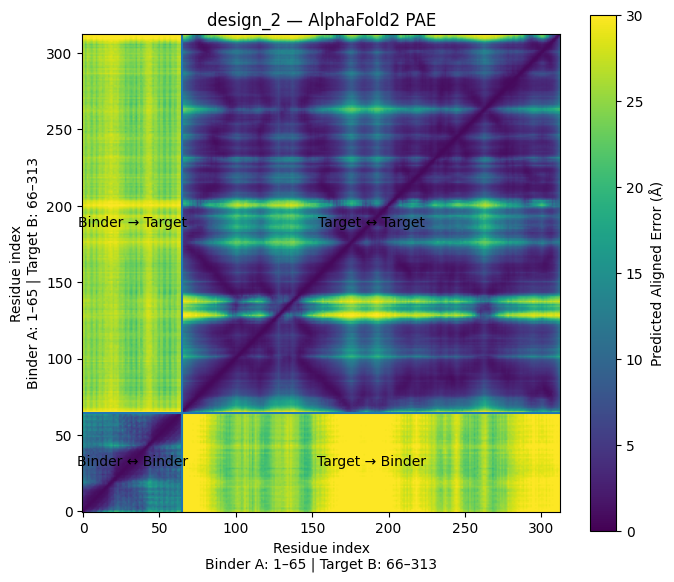

Saved: /content/af2_results/design_2_PAE_heatmap.png
design_0: binder=67, target=248, PAE shape=(315, 315)


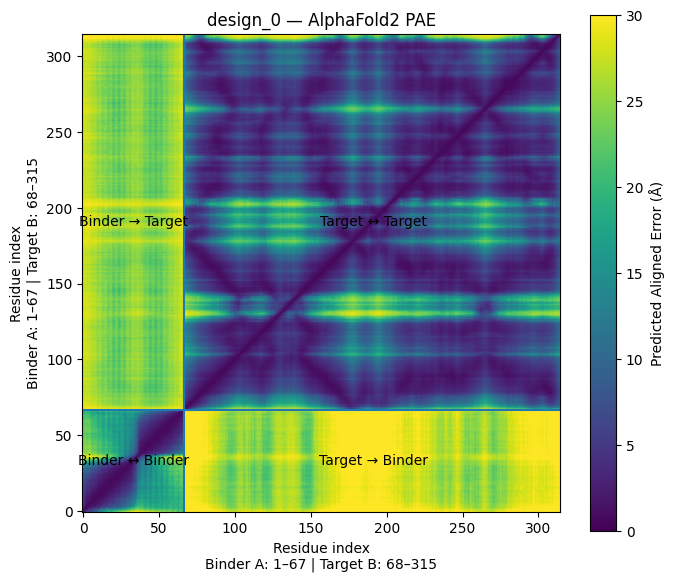

Saved: /content/af2_results/design_0_PAE_heatmap.png
design_4: binder=58, target=248, PAE shape=(306, 306)


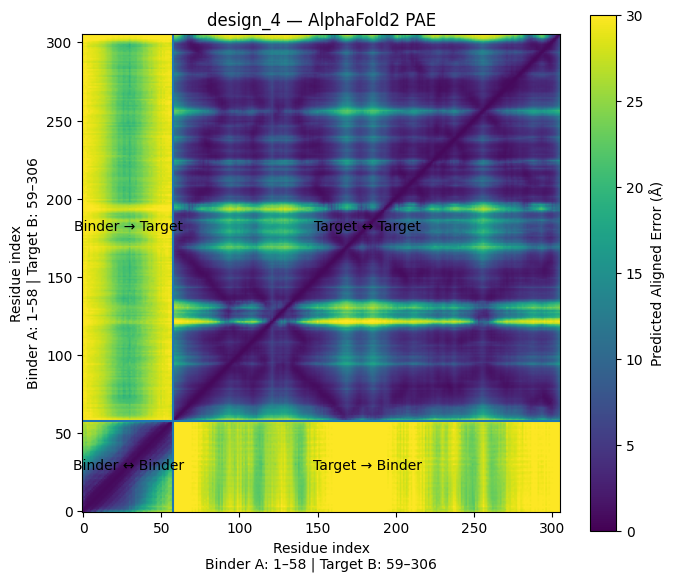

Saved: /content/af2_results/design_4_PAE_heatmap.png


In [7]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

AF_DIR = Path("/content/af2_results")

DESIGNS = [
    "design_2",
    "design_0",
    "design_4",
]

BINDER_CHAIN = "A"
TARGET_CHAIN = "B"


def get_chain_lengths(pdb_file):
    residues = {}

    with open(pdb_file) as f:
        for line in f:
            if not line.startswith("ATOM"):
                continue

            chain = line[21].strip()
            resi = line[22:26].strip()

            key = (chain, resi)

            if chain not in residues:
                residues[chain] = set()

            residues[chain].add(key)

    return {
        chain: len(vals)
        for chain, vals in residues.items()
    }


def find_score_json(design):

    patterns = [
        f"*{design}*scores*rank_001*.json",
        f"*{design}*scores*.json",
        f"*{design}*.json",
    ]

    for pattern in patterns:
        files = sorted(AF_DIR.rglob(pattern))
        if files:
            return files[0]

    return None


def find_af_pdb(design):

    patterns = [
        f"*{design}*rank_001*.pdb",
        f"*{design}*.pdb",
    ]

    for pattern in patterns:
        files = sorted(AF_DIR.rglob(pattern))
        if files:
            return files[0]

    return None


def load_pae(json_file):

    with open(json_file) as f:
        data = json.load(f)

    pae = data.get("pae")

    if pae is None:
        pae = data.get("predicted_aligned_error")

    if pae is None:
        raise ValueError(
            f"No PAE matrix found in {json_file}"
        )

    return np.array(pae)


for design in DESIGNS:

    af_pdb = find_af_pdb(design)
    score_json = find_score_json(design)

    if af_pdb is None:
        print(f"{design}: AF2 PDB not found")
        continue

    if score_json is None:
        print(f"{design}: score JSON not found")
        continue

    chain_lengths = get_chain_lengths(af_pdb)

    binder_len = chain_lengths.get(BINDER_CHAIN, 0)
    target_len = chain_lengths.get(TARGET_CHAIN, 0)

    pae = load_pae(score_json)

    print(
        f"{design}: "
        f"binder={binder_len}, "
        f"target={target_len}, "
        f"PAE shape={pae.shape}"
    )

    boundary = binder_len

    plt.figure(figsize=(7, 6))

    im = plt.imshow(
        pae,
        origin="lower",
        vmin=0,
        vmax=30
    )

    plt.colorbar(
        im,
        label="Predicted Aligned Error (Å)"
    )

    # boundary between binder and target
    plt.axvline(
        boundary - 0.5,
        linewidth=1.5
    )

    plt.axhline(
        boundary - 0.5,
        linewidth=1.5
    )

    # labels in each quadrant
    total = pae.shape[0]

    plt.text(
        binder_len / 2,
        binder_len / 2,
        "Binder ↔ Binder",
        ha="center",
        va="center"
    )

    plt.text(
        binder_len + target_len / 2,
        binder_len / 2,
        "Target → Binder",
        ha="center",
        va="center"
    )

    plt.text(
        binder_len / 2,
        binder_len + target_len / 2,
        "Binder → Target",
        ha="center",
        va="center"
    )

    plt.text(
        binder_len + target_len / 2,
        binder_len + target_len / 2,
        "Target ↔ Target",
        ha="center",
        va="center"
    )

    plt.xlabel(
        f"Residue index\n"
        f"Binder A: 1–{binder_len} | "
        f"Target B: {binder_len+1}–{total}"
    )

    plt.ylabel(
        f"Residue index\n"
        f"Binder A: 1–{binder_len} | "
        f"Target B: {binder_len+1}–{total}"
    )

    plt.title(
        f"{design} — AlphaFold2 PAE"
    )

    plt.tight_layout()

    out = AF_DIR / f"{design}_PAE_heatmap.png"

    plt.savefig(
        out,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", out)

In [8]:
from pathlib import Path
import numpy as np
from Bio.PDB import PDBParser, Superimposer, PDBIO

RF_DIR = Path("/content/rfd1_outputs")
AF_DIR = Path("/content/af2_results")

DESIGNS = [
    "design_2",
    "design_0",
    "design_4",
]

BINDER_CHAIN = "A"


def find_af_pdb(design):

    patterns = [
        f"*{design}*rank_001*.pdb",
        f"*{design}*.pdb",
    ]

    for pattern in patterns:
        files = sorted(AF_DIR.rglob(pattern))

        if files:
            return files[0]

    return None


def get_ca_atoms(structure, chain_id):

    atoms = []

    chain = structure[0][chain_id]

    for residue in chain:

        if "CA" in residue:
            atoms.append(
                residue["CA"]
            )

    return atoms


parser = PDBParser(QUIET=True)

results = []


for design in DESIGNS:

    rf_pdb = RF_DIR / f"{design}.pdb"
    af_pdb = find_af_pdb(design)

    if not rf_pdb.exists():

        print(
            f"{design}: RF PDB missing"
        )

        continue


    if af_pdb is None:

        print(
            f"{design}: AF2 PDB missing"
        )

        continue


    rf_structure = parser.get_structure(
        f"{design}_RF",
        str(rf_pdb)
    )

    af_structure = parser.get_structure(
        f"{design}_AF2",
        str(af_pdb)
    )


    rf_atoms = get_ca_atoms(
        rf_structure,
        BINDER_CHAIN
    )

    af_atoms = get_ca_atoms(
        af_structure,
        BINDER_CHAIN
    )


    print("\n" + "=" * 60)
    print(design)
    print("RF binder residues :", len(rf_atoms))
    print("AF2 binder residues:", len(af_atoms))


    if len(rf_atoms) != len(af_atoms):

        print(
            "Cannot calculate RMSD: "
            "different binder lengths"
        )

        continue


    if len(rf_atoms) == 0:

        print(
            "No CA atoms found"
        )

        continue


    # ---------------------------------------------
    # Align AF2 binder onto RFdiffusion binder
    # ---------------------------------------------

    sup = Superimposer()

    sup.set_atoms(
        rf_atoms,
        af_atoms
    )

    rmsd = sup.rms


    # Apply transformation to entire AF2 structure
    sup.apply(
        list(
            af_structure.get_atoms()
        )
    )


    print(
        f"Binder RMSD = {rmsd:.3f} Å"
    )


    # ---------------------------------------------
    # Save aligned AF2 structure
    # ---------------------------------------------

    out_pdb = (
        AF_DIR /
        f"{design}_AF2_aligned_to_RF.pdb"
    )

    io = PDBIO()

    io.set_structure(
        af_structure
    )

    io.save(
        str(out_pdb)
    )


    print(
        "Saved aligned PDB:",
        out_pdb
    )


    results.append({
        "Design": design,
        "Binder_RMSD_A": rmsd,
        "Aligned_AF2_PDB": str(out_pdb)
    })


design_2
RF binder residues : 65
AF2 binder residues: 65
Binder RMSD = 6.323 Å
Saved aligned PDB: /content/af2_results/design_2_AF2_aligned_to_RF.pdb

design_0
RF binder residues : 67
AF2 binder residues: 67
Binder RMSD = 4.130 Å
Saved aligned PDB: /content/af2_results/design_0_AF2_aligned_to_RF.pdb

design_4
RF binder residues : 58
AF2 binder residues: 58
Binder RMSD = 5.515 Å
Saved aligned PDB: /content/af2_results/design_4_AF2_aligned_to_RF.pdb
